In [ ]:
import copy
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. GPU Modu Kurulumu ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 2. Sistem Bilgilendirmesi ---
print(f"PyTorch Versiyonu: {torch.__version__}")

if torch.cuda.is_available():
    print(f"✅ GPU Aktif: {torch.cuda.get_device_name(0)}")
    print(f"✅ CUDA: {torch.version.cuda}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️ GPU bulunamadı, CPU kullanılıyor.")

print(f"🚀 Aktif Cihaz: {device.type.upper()}")

PyTorch Versiyonu: 2.12.0.dev20260329+cu128
✅ GPU Aktif: NVIDIA GeForce RTX 5070
✅ CUDA: 12.8
💾 VRAM: 11.9 GB
🚀 Aktif Cihaz: CUDA


In [ ]:
import pandas as pd

file_path = r'C:\Users\oztur\Documents\project1\lending-club\accepted_2007_to_2018Q4.csv.gz'

try:
    print("🚀 Büyük veri seti yükleniyor ve açılıyor...")
    # compression='gzip' olarak düzeltildi
    df = pd.read_csv(file_path, compression='gzip', low_memory=False)

    print("✅ Dosya başarıyla yüklendi!")
    print(df.head())
except Exception as e:
    print(f"❌ Hata: {e}")

🚀 Büyük veri seti yükleniyor ve açılıyor...
✅ Dosya başarıyla yüklendi!
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...        

In [ ]:
import pandas as pd

file_path = r'C:\Users\oztur\Documents\project1\lending-club\accepted_2007_to_2018Q4.csv.gz'

try:
    print("🚀 Veri yükleniyor...")
    df = pd.read_csv(file_path, compression='gzip', low_memory=False)
    print(f"✅ Yüklendi! Satır: {len(df):,} | Sütun: {len(df.columns)}")
    print(df.head())
except Exception as e:
    print(f"❌ Hata: {e}")

🚀 Veri yükleniyor...
✅ Yüklendi! Satır: 2,260,701 | Sütun: 151
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                 

In [ ]:
file_path = r'C:\Users\oztur\Documents\project1\lending-club\accepted_2007_to_2018Q4.csv.gz'

df = pd.read_csv(file_path, nrows=200000, low_memory=False, compression='gzip')

print(f"Shape: {df.shape}")
print(df['loan_status'].value_counts())

Shape: (200000, 151)
loan_status
Fully Paid            140992
Charged Off            35090
Current                22637
Late (31-120 days)       785
In Grace Period          347
Late (16-30 days)        148
Default                    1
Name: count, dtype: int64


In [ ]:
df_raw = pd.read_csv(file_path, nrows=200000, low_memory=False, compression='gzip')
df_raw = df_raw[df_raw['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df_raw = df_raw.select_dtypes(include=[np.number])

# Eksik değer oranı %20'den az olan kolonları göster
missing = df_raw.isnull().mean()
good = missing[missing < 0.2].index.tolist()
print(f"Kullanılabilir kolon sayısı: {len(good)}")
print(good)

Kullanılabilir kolon sayısı: 70
['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_

In [ ]:
df = pd.read_csv(file_path, nrows=200000, low_memory=False, compression='gzip')
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['label'] = (df['loan_status'] == 'Charged Off').astype(int)
df = df.drop(columns=['loan_status'])
df = df.select_dtypes(include=[np.number])

# Eksik değer oranı %20'den az olan kolonları kullan
missing = df.isnull().mean()
good_cols = missing[missing < 0.2].index.tolist()

# id kolonunu çıkar (anlamsız)
good_cols = [c for c in good_cols if c != 'id']

# Eksik değerleri median ile doldur
df = df[good_cols]
df = df.fillna(df.median())

print(f"Temizlenmiş shape: {df.shape}")
print(f"Kullanılan kolon sayısı: {len(good_cols)-1} feature + 1 label")
print(f"\nLabel dağılımı:")
print(df['label'].value_counts())

Temizlenmiş shape: (176082, 70)
Kullanılan kolon sayısı: 69 feature + 1 label

Label dağılımı:
label
0    140992
1     35090
Name: count, dtype: int64


C:\Users\oztur\AppData\Local\Temp\ipykernel_13224\1388229310.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = (df['loan_status'] == 'Charged Off').astype(int)


In [ ]:
class LendingClubDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def split_iid(dataset_size, num_users):
    all_idxs = np.arange(dataset_size)
    np.random.shuffle(all_idxs)
    user_groups = {}
    items_per_user = dataset_size // num_users
    for i in range(num_users):
        user_groups[i] = all_idxs[i * items_per_user: (i+1) * items_per_user]
    return user_groups

In [ ]:
K = 50

features = df.drop(columns=['label']).values
labels = df['label'].values

scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

train_dataset_lc = LendingClubDataset(X_train, y_train)
test_dataset_lc  = LendingClubDataset(X_test, y_test)

user_groups_lc = split_iid(len(X_train), K)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Her istemcide: {len(user_groups_lc[0])} örnek")

Train: (140865, 69), Test: (35217, 69)
Her istemcide: 2817 örnek


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

input_dim_lc = X_train.shape[1]
print(f"Input dim: {input_dim_lc}")
print(MLP(input_dim_lc))

Input dim: 69
MLP(
  (net): Sequential(
    (0): Linear(in_features=69, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:
def local_update(model, dataset, idxs, lr=1e-3, batch_size=128,
                 local_epochs=1, malicious=False):
    model = copy.deepcopy(model).to(device)  # ✅ model GPU'ya taşındı
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    subset = Subset(dataset, list(idxs))
    loader = DataLoader(subset, batch_size=batch_size, shuffle=True,
                        num_workers=0, pin_memory=True)  # ✅ GPU veri transferi hızlandı
    epoch_loss = []
    for _ in range(local_epochs):
        batch_losses = []
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)  # ✅ non_blocking
            optimizer.zero_grad()
            if malicious:
                y_batch = 1 - y_batch
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        epoch_loss.append(np.mean(batch_losses))
    return model.state_dict(), np.mean(epoch_loss)

def average_weights(w_list):
    w_avg = copy.deepcopy(w_list[0])
    for key in w_avg.keys():
        for i in range(1, len(w_list)):
            w_avg[key] += w_list[i][key]
        w_avg[key] = torch.div(w_avg[key], len(w_list))
    return w_avg

def test_model(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=512,  # ✅ GPU'da batch büyütüldü
                        num_workers=0, pin_memory=True)
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
            preds = (model(X_batch) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    return correct / total

print("✅ FL fonksiyonları hazır.")

✅ FL fonksiyonları hazır.


In [ ]:
INITIAL_TOKENS = 64
GAMMA_P = 8
GAMMA_V = 8
EPSILON = 0.05

def initialize_tokens(num_clients):
    return {i: float(INITIAL_TOKENS) for i in range(num_clients)}

def local_validation_score(model, dataset, idxs):
    model.eval()
    subset = Subset(dataset, list(idxs))
    val_size = max(1, int(0.2 * len(subset)))
    val_subset = Subset(subset, list(range(val_size)))
    loader = DataLoader(val_subset, batch_size=128,  # ✅ 64→128 GPU'da daha verimli
                        pin_memory=True, num_workers=0)
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
            preds = (model(X_batch) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    return correct / total if total > 0 else 0.0

def majority_vote(voter_scores, prev_scores, epsilon=EPSILON):
    votes = {}
    for voter_id, score in voter_scores.items():
        prev = prev_scores.get(voter_id, 0.0)
        if prev == 0.0:
            votes[voter_id] = 1
        elif score >= (1 - epsilon) * prev:
            votes[voter_id] = 1
        else:
            votes[voter_id] = -1
    decision = 1 if sum(votes.values()) > 0 else -1
    return decision, votes

def reward_slash_proposers(tokens, proposer_ids, decision, gamma_p=GAMMA_P):
    pool = 0.0
    removed = set()
    if decision == -1:
        for idx in proposer_ids:
            slash = min(tokens[idx], gamma_p)
            tokens[idx] -= slash
            pool += slash
            if tokens[idx] == 0:
                removed.add(idx)
    else:
        if pool > 0:
            reward = pool / len(proposer_ids)
            for idx in proposer_ids:
                tokens[idx] += reward
    return tokens, removed, pool

def reward_slash_voters(tokens, votes, decision, gamma_v=GAMMA_V):
    pool = 0.0
    removed = set()
    majority = [idx for idx, v in votes.items() if v == decision]
    minority  = [idx for idx, v in votes.items() if v != decision]
    for idx in minority:
        slash = min(tokens[idx], gamma_v)
        tokens[idx] -= slash
        pool += slash
        if tokens[idx] == 0:
            removed.add(idx)
    if pool > 0 and majority:
        reward = pool / len(majority)
        for idx in majority:
            tokens[idx] += reward
    return tokens, removed

print("✅ Token ve voting fonksiyonları hazır.")

✅ Token ve voting fonksiyonları hazır.


In [ ]:
import gc
import pickle

NUM_ROUNDS = 100
PROPOSER_FRAC = 0.1
eta_values = [0.1, 0.2, 0.3, 0.4]
results_lc = {}

for eta in eta_values:
    print(f"\n--- FedAVG w/ mal | eta = {eta} ---")
    num_malicious = int(K * eta)
    malicious_clients = set(np.random.choice(range(K), num_malicious, replace=False))
    global_model = MLP(input_dim=input_dim_lc).to(device)
    test_accuracies = []

    for round_idx in tqdm(range(NUM_ROUNDS)):
        num_proposers = max(int(PROPOSER_FRAC * K), 1)
        proposer_ids = np.random.choice(range(K), num_proposers, replace=False)
        local_weights = []
        for idx in proposer_ids:
            w, _ = local_update(global_model, train_dataset_lc,
                                user_groups_lc[idx],
                                malicious=(idx in malicious_clients))
            local_weights.append(w)
        global_model.load_state_dict(average_weights(local_weights))

        if (round_idx + 1) % 10 == 0:
            acc = test_model(global_model, test_dataset_lc)
            test_accuracies.append(acc)
            print(f"Round {round_idx+1} | Accuracy: {acc:.4f}")
            torch.save(global_model.state_dict(), f"checkpoint_lc_eta{eta}_round{round_idx+1}.pt")

    results_lc[eta] = test_accuracies
    print(f"✅ Son accuracy: {test_accuracies[-1]:.4f}")

    with open("results_lc_backup.pkl", "wb") as f:
        pickle.dump(results_lc, f)
    print(f"💾 results_lc kaydedildi (eta={eta} tamamlandı)")

    del global_model
    torch.cuda.empty_cache()
    gc.collect()


--- FedAVG w/ mal | eta = 0.1 ---


 10%|█         | 10/100 [00:03<00:23,  3.87it/s]

Round 10 | Accuracy: 0.9881


 20%|██        | 20/100 [00:05<00:18,  4.34it/s]

Round 20 | Accuracy: 0.9800


...

Round 80 | Accuracy: 0.9922


 90%|█████████ | 90/100 [00:15<00:02,  4.75it/s]

Round 90 | Accuracy: 0.2264


100%|██████████| 100/100 [00:17<00:00,  5.79it/s]

Round 100 | Accuracy: 0.8466
✅ Son accuracy: 0.8466
💾 results_lc kaydedildi (eta=0.4 tamamlandı)


**Section 7 — Blockchain Destekli FL Eğitim Döngüsü**



In [ ]:
import pickle
blockchain_results_lc = {}

for eta in eta_values:
    print(f"\n--- Blockchain FL | eta = {eta} ---")
    num_malicious = int(K * eta)
    malicious_clients = set(np.random.choice(range(K), num_malicious, replace=False))
    tokens = initialize_tokens(K)
    active_clients = set(range(K))
    global_model = MLP(input_dim=input_dim_lc).to(device)
    prev_val_scores = {}
    test_accuracies = []
    token_history_mal = []
    token_history_hon = []

    for round_idx in tqdm(range(NUM_ROUNDS)):
        active_list = list(active_clients)
        if len(active_list) < 3:
            print(f"Yeterli istemci kalmadı, round {round_idx}'de duruldu.")
            break
        num_proposers = max(int(PROPOSER_FRAC * len(active_list)), 1)
        proposer_ids = list(np.random.choice(active_list, num_proposers, replace=False))
        voter_ids = [i for i in active_list if i not in proposer_ids]

        local_weights = []
        for idx in proposer_ids:
            w, _ = local_update(global_model, train_dataset_lc,
                                user_groups_lc[idx],
                                malicious=(idx in malicious_clients))
            local_weights.append(w)

        candidate_model = MLP(input_dim=input_dim_lc).to(device)
        candidate_model.load_state_dict(average_weights(local_weights))

        voter_scores = {}
        for idx in voter_ids:
            score = local_validation_score(candidate_model, train_dataset_lc,
                                           user_groups_lc[idx])
            voter_scores[idx] = 1.0 - score if idx in malicious_clients else score

        decision, votes = majority_vote(voter_scores, prev_val_scores)

        if decision == 1:
            global_model.load_state_dict(candidate_model.state_dict())
            for idx, score in voter_scores.items():
                prev_val_scores[idx] = score

        tokens, removed_p, _ = reward_slash_proposers(tokens, proposer_ids, decision)
        tokens, removed_v    = reward_slash_voters(tokens, votes, decision)
        active_clients -= (removed_p | removed_v)

        # ✅ candidate_model VRAM'den temizle
        del candidate_model
        torch.cuda.empty_cache()

        mal_tokens = [tokens[i] for i in active_clients if i in malicious_clients]
        hon_tokens = [tokens[i] for i in active_clients if i not in malicious_clients]
        token_history_mal.append(np.mean(mal_tokens) if mal_tokens else 0)
        token_history_hon.append(np.mean(hon_tokens) if hon_tokens else 0)

        if (round_idx + 1) % 10 == 0:
            acc = test_model(global_model, test_dataset_lc)
            test_accuracies.append(acc)
            mal_rem = len([i for i in active_clients if i in malicious_clients])
            print(f"Round {round_idx+1} | Acc: {acc:.4f} | "
                  f"Aktif: {len(active_clients)} | Mal: {mal_rem}")
            # ✅ Her 10 round'da checkpoint kaydet
            torch.save(global_model.state_dict(),
                      f"checkpoint_blockchain_lc_eta{eta}_round{round_idx+1}.pt")

    blockchain_results_lc[eta] = {
        'accuracies': test_accuracies,
        'token_mal': token_history_mal,
        'token_hon': token_history_hon
    }

    # ✅ Her eta bitince kaydet
    with open("blockchain_results_lc_backup.pkl", "wb") as f:
        pickle.dump(blockchain_results_lc, f)
    print(f"💾 blockchain_results_lc kaydedildi (eta={eta} tamamlandı)")

    # ✅ VRAM temizle
    del global_model
    torch.cuda.empty_cache()
    gc.collect()

print("\n✅ Lending Club Blockchain FL tamamlandı.")


--- Blockchain FL | eta = 0.1 ---


 10%|█         | 10/100 [00:03<00:32,  2.79it/s]

Round 10 | Acc: 0.9889 | Aktif: 50 | Mal: 5


 20%|██        | 20/100 [00:06<00:25,  3.11it/s]

Round 20 | Acc: 0.9924 | Aktif: 45 | Mal: 0


...

Round 80 | Acc: 0.9944 | Aktif: 30 | Mal: 0


 90%|█████████ | 90/100 [00:19<00:02,  4.47it/s]

Round 90 | Acc: 0.9957 | Aktif: 30 | Mal: 0


100%|██████████| 100/100 [00:21<00:00,  4.70it/s]

Round 100 | Acc: 0.9958 | Aktif: 30 | Mal: 0
💾 blockchain_results_lc kaydedildi (eta=0.4 tamamlandı)

✅ Lending Club Blockchain FL tamamlandı.


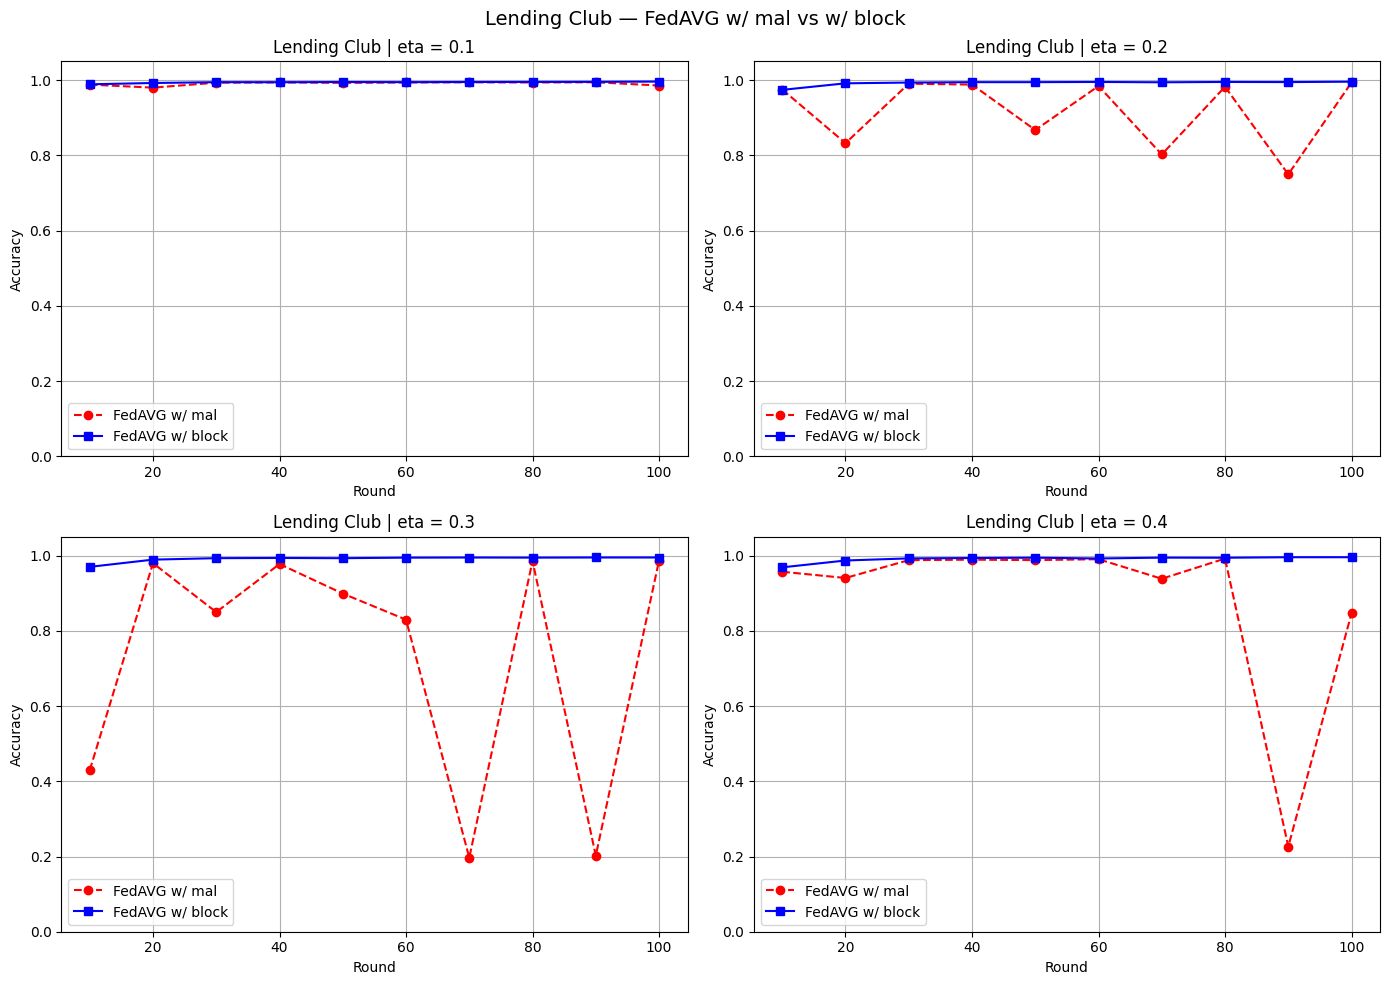


--- Lending Club Özet Tablosu ---
eta    w/ mal       w/ block
------------------------------
0.1    0.9924       0.9953
0.2    0.9025       0.9951
0.3    0.6404       0.9949
0.4    0.7988       0.9946


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, eta in enumerate(eta_values):
    ax = axes[i]
    ax.plot(range(10, NUM_ROUNDS+1, 10), results_lc[eta],
            marker='o', label='FedAVG w/ mal', color='red', linestyle='--')
    bc_acc = blockchain_results_lc[eta]['accuracies']
    ax.plot(range(10, len(bc_acc)*10+1, 10), bc_acc,
            marker='s', label='FedAVG w/ block', color='blue')
    ax.set_title(f'Lending Club | eta = {eta}')
    ax.set_xlabel('Round')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0, 1.05)

plt.suptitle('Lending Club — FedAVG w/ mal vs w/ block', fontsize=14)
plt.tight_layout()
plt.savefig('lc_comparison.png', dpi=150)
plt.show()

# Özet tablo
print("\n--- Lending Club Özet Tablosu ---")
print(f"{'eta':<6} {'w/ mal':<12} {'w/ block'}")
print("-" * 30)
for eta in eta_values:
    mal_acc = np.mean(results_lc[eta][-5:])
    blk_acc = np.mean(blockchain_results_lc[eta]['accuracies'][-5:]) \
              if blockchain_results_lc[eta]['accuracies'] else 0
    print(f"{eta:<6} {mal_acc:<12.4f} {blk_acc:.4f}")

In [ ]:
import os
import copy
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt

# VRAM yönetimi için açıyoruz
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# --- GPU'ya geçiş ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"🚀 Aktif Cihaz: {device.type.upper()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_ram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"✅ GPU Aktif: {gpu_name} ({gpu_ram:.1f} GB VRAM)")
    print(f"✅ CUDA Sürümü: {torch.version.cuda}")

    # RTX 5070 için performans optimizasyonları
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    print("⚠️ GPU bulunamadı, CPU kullanılıyor.")

🚀 Aktif Cihaz: CUDA
✅ GPU Aktif: NVIDIA GeForce RTX 5070 (11.9 GB VRAM)
✅ CUDA Sürümü: 12.8


In [ ]:
# Bunu çalıştır - kernel hatası gelmiyor mu?
import torch
x = torch.randn(1000, 1000).cuda()
y = torch.randn(1000, 1000).cuda()
z = x @ y
print("✅ GPU hesaplama çalışıyor!", z.shape)

✅ GPU hesaplama çalışıyor! torch.Size([1000, 1000])


In [ ]:
import os
import pandas as pd

# 1. DOSYA YOLU AYARI
base_path = r'C:\Users\oztur\Documents\project1\data'
label_path = os.path.join(base_path, 'Data_Entry_2017.csv')

try:
    df_cxr = pd.read_csv(label_path)
    print("✅ CSV dosyası başarıyla okundu.")
except FileNotFoundError:
    print(f"❌ Dosya bulunamadı! Yolu kontrol et: {label_path}")

TOP10_DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema'
]

# 2. GÖRÜNTÜ DOSYALARINI TOPLAMA
available_images = {}

for i in range(1, 13):
    folder_name = f'images_{str(i).zfill(3)}'
    folder_path = os.path.join(base_path, folder_name)

    if os.path.exists(folder_path):
        for root, dirs, files in os.walk(folder_path):
            for fname in files:
                if fname.endswith('.png'):
                    available_images[fname] = os.path.join(root, fname)

print(f"📸 Sistemde bulunan toplam görüntü: {len(available_images)}")

# 3. VERİYİ FİLTRELEME VE ENCODING
df_cxr = df_cxr[df_cxr['Image Index'].isin(available_images.keys())].head(60000).copy()

for disease in TOP10_DISEASES:
    df_cxr[disease] = df_cxr['Finding Labels'].apply(
        lambda x: 1 if disease in x else 0
    )

print(f"\n🎯 Kullanılacak nihai görüntü sayısı: {len(df_cxr)}")
print("-" * 30)
print("🦠 Hastalık Dağılımı (Sınıf Frekansları):")
print(df_cxr[TOP10_DISEASES].sum().sort_values(ascending=False))

# GPU bellek durumunu göster
if torch.cuda.is_available():
    free_mem = torch.cuda.mem_get_info()[0] / 1024**3
    total_mem = torch.cuda.mem_get_info()[1] / 1024**3
    print(f"\n💾 GPU Bellek: {free_mem:.1f} GB boş / {total_mem:.1f} GB toplam")

✅ CSV dosyası başarıyla okundu.
📸 Sistemde bulunan toplam görüntü: 112120

🎯 Kullanılacak nihai görüntü sayısı: 60000
------------------------------
🦠 Hastalık Dağılımı (Sınıf Frekansları):
Infiltration     9330
Effusion         6607
Atelectasis      5955
Nodule           3067
Mass             2777
Consolidation    2521
Pneumothorax     2454
Cardiomegaly     1565
Edema            1189
Pneumonia         749
dtype: int64

💾 GPU Bellek: 10.5 GB boş / 11.9 GB toplam


In [ ]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, available_images, transform=None):
        self.df = df.reset_index(drop=True)
        self.available_images = available_images
        self.transform = transform
        self.diseases = TOP10_DISEASES

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.available_images[row['Image Index']]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(
            row[self.diseases].values.astype(float),
            dtype=torch.float32
        )
        return img, label

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ✅ GPU için standart
                         std=[0.229, 0.224, 0.225])     # Lambda yerine Normalize
])

print("✅ Dataset sınıfı hazır.")
print(f"🖼️  Görüntü boyutu: 112x112")
print(f"⚡ GPU'ya optimize Normalize kullanılıyor.")

✅ Dataset sınıfı hazır.
🖼️  Görüntü boyutu: 112x112
⚡ GPU'ya optimize Normalize kullanılıyor.


In [ ]:
from PIL import Image
import torch
from torchvision import transforms
from torch.utils.data import TensorDataset
from tqdm import tqdm # Yükleme çubuğu için

# 1. Görüntü küçültme ve tensöre çevirme ayarları (RAM'i koruyan sihir)
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 2. Hata aldığın o meşhur fonksiyonun asıl tanımı
def preload_images(df, available_images, transform):
    images, labels = [], []
    # tqdm ekledik ki 60.000 fotoğraf yüklenirken ekranda ilerlemeyi görebilesin
    for idx in tqdm(range(len(df)), desc="RAM'e Yükleniyor"):
        row = df.iloc[idx]
        img = Image.open(available_images[row['Image Index']]).convert('RGB')
        images.append(transform(img))

        # Uyarı: TOP10_DISEASES listesinin bu hücreden önce tanımlı olduğundan emin ol
        labels.append(torch.tensor(row[TOP10_DISEASES].values.astype(float), dtype=torch.float32))

    return torch.stack(images), torch.stack(labels)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

K = 50

# df_cxr'nin 60.000 satır olduğunu varsayarak %80/%20 bölme (48.000 ve 12.000)
train_df, test_df = train_test_split(df_cxr, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"📊 Orijinal Eğitim Seti Boyutu: {len(train_df)} fotoğraf")
print(f"📊 Orijinal Test Seti Boyutu: {len(test_df)} fotoğraf")
print(f"📁 Klasördeki Toplam Fotoğraf: {len(available_images)}")

# --- 🚀 DEĞİŞEN KISIM BURASI ---
# .head() kısıtlamalarını kaldırdık. Verinin tamamını kullanıyoruz.
train_df_s = train_df.copy()
test_df_s  = test_df.copy()

# ⚠️ ÇOK KRİTİK UYARI:
# Hızın tekrar 70 saniyelere düşmemesi için ChestXrayDataset sınıfı yerine,
# bir önceki adımda kurduğumuz RAM'e yükleme (preload_images) sistemini kullanmalısın.

print("🚀 Görüntüler RAM'e yükleniyor... (Tam kapasite 7-10 dk sürebilir)")
train_X, train_y = preload_images(train_df_s, available_images, transform)
test_X, test_y = preload_images(test_df_s, available_images, transform)

train_dataset_cxr = TensorDataset(train_X, train_y)
test_dataset_cxr  = TensorDataset(test_X, test_y)

# --------------------------------

def split_noniid(df, num_users):
    user_groups = {i: [] for i in range(num_users)}
    for disease_idx, disease in enumerate(TOP10_DISEASES):
        disease_idxs = df[df[disease] == 1].index.tolist()
        np.random.shuffle(disease_idxs)
        dominant_users = [(disease_idx * 5 + j) % num_users for j in range(5)]
        per_user = max(1, len(disease_idxs) // len(dominant_users))
        for i, user in enumerate(dominant_users):
            user_groups[user].extend(disease_idxs[i*per_user:(i+1)*per_user])
    all_assigned = set(idx for idxs in user_groups.values() for idx in idxs)
    remaining = [i for i in range(len(df)) if i not in all_assigned]
    np.random.shuffle(remaining)
    per_user = len(remaining) // num_users
    for i in range(num_users):
        user_groups[i].extend(remaining[i*per_user:(i+1)*per_user])
    return {k: np.array(list(set(v))) for k, v in user_groups.items()}

user_groups_cxr = split_noniid(train_df_s, K)

print(f"✅ Train: {len(train_df_s)}, Test: {len(test_df_s)}")
print(f"✅ Her istemcide ortalama: {np.mean([len(v) for v in user_groups_cxr.values()]):.0f} örnek")

📊 Orijinal Eğitim Seti Boyutu: 48000 fotoğraf
📊 Orijinal Test Seti Boyutu: 12000 fotoğraf
📁 Klasördeki Toplam Fotoğraf: 112120
🚀 Görüntüler RAM'e yükleniyor... (Tam kapasite 7-10 dk sürebilir)


RAM'e Yükleniyor: 100%|██████████| 12000/12000 [02:02<00:00, 97.61it/s] 


✅ Train: 48000, Test: 12000
✅ Her istemcide ortalama: 1148 örnek


In [ ]:
import gc
import torch
import torch.nn as nn
import torchvision.models as models

torch.cuda.empty_cache()
gc.collect()

class DenseNet121(nn.Module):
    def __init__(self, num_classes=10):
        super(DenseNet121, self).__init__()
        self.densenet = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1
        )
        in_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.densenet(x)

model_test = DenseNet121().to(device)
total = sum(p.numel() for p in model_test.parameters())

print(f"✅ DenseNet121 Hazır!")
print(f"📊 Toplam parametre: {total:,}")

# ✅ GPU bellek durumu
if torch.cuda.is_available():
    used = torch.cuda.memory_allocated() / 1024**2
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**2
    print(f"💾 GPU Bellek: {used:.0f} MB kullanımda / {total_mem:.0f} MB toplam")

del model_test
torch.cuda.empty_cache()
gc.collect()

✅ DenseNet121 Hazır!
📊 Toplam parametre: 6,964,106
💾 GPU Bellek: 103 MB kullanımda / 12227 MB toplam


136

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import roc_auc_score

def local_update_cxr(model, dataset, idxs, lr=1e-3, batch_size=512,
                     local_epochs=1, malicious=False):
    model_copy = DenseNet121().to(device)
    model_copy.load_state_dict(model.state_dict())
    model_copy.train()
    optimizer = torch.optim.Adam(model_copy.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler('cuda')  # ✅ eklendi
    subset = Subset(dataset, list(idxs))
    loader = DataLoader(subset, batch_size=batch_size, shuffle=True,
                        num_workers=0, pin_memory=True)
    epoch_loss = []

    for _ in range(local_epochs):
        batch_losses = []
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            if malicious:
                y_batch = 1 - y_batch
            with torch.amp.autocast('cuda'):
                preds = model_copy(X_batch)
                loss = criterion(preds, y_batch)
            scaler.scale(loss).backward()  # ✅ değişti
            scaler.step(optimizer)          # ✅ değişti
            scaler.update()                 # ✅ eklendi
            batch_losses.append(loss.item())
        epoch_loss.append(np.mean(batch_losses))

    state = {k: v.cpu() for k, v in model_copy.state_dict().items()}
    del model_copy
    torch.cuda.empty_cache()
    return state, np.mean(epoch_loss)

def average_weights(w_list):
    w_avg = copy.deepcopy(w_list[0])
    for key in w_avg.keys():
        for i in range(1, len(w_list)):
            w_avg[key] += w_list[i][key]
        w_avg[key] = torch.div(w_avg[key], len(w_list))
    return w_avg

def test_model_cxr(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256,
                        num_workers=0, pin_memory=True)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                preds = torch.sigmoid(model(X_batch)).cpu().float().numpy()
            all_preds.append(preds)
            all_labels.append(y_batch.numpy())
    torch.cuda.empty_cache()
    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    aurocs = []
    for i in range(len(TOP10_DISEASES)):
        if len(np.unique(all_labels[:, i])) > 1:
            aurocs.append(roc_auc_score(all_labels[:, i], all_preds[:, i]))
    return np.mean(aurocs) if aurocs else 0.0

def local_validation_score_cxr(model, dataset, idxs):
    model.eval()
    subset = Subset(dataset, list(idxs))
    val_size = max(1, int(0.2 * len(subset)))
    val_subset = Subset(subset, list(range(val_size)))
    loader = DataLoader(val_subset, batch_size=128,
                        num_workers=0, pin_memory=True)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                preds = torch.sigmoid(model(X_batch)).cpu().float().numpy()
            all_preds.append(preds)
            all_labels.append(y_batch.numpy())
    torch.cuda.empty_cache()
    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    aurocs = []
    for i in range(len(TOP10_DISEASES)):
        if len(np.unique(all_labels[:, i])) > 1:
            aurocs.append(roc_auc_score(all_labels[:, i], all_preds[:, i]))
    return np.mean(aurocs) if aurocs else 0.0

print("✅ FL fonksiyonları GPU için hazır ve optimize edildi.")

✅ FL fonksiyonları GPU için hazır ve optimize edildi.


In [ ]:
INITIAL_TOKENS = 64
GAMMA_P = 8
GAMMA_V = 8
EPSILON = 0.05

def initialize_tokens(num_clients):
    return {i: float(INITIAL_TOKENS) for i in range(num_clients)}

def majority_vote(voter_scores, prev_scores, epsilon=EPSILON):
    votes = {}
    for voter_id, score in voter_scores.items():
        prev = prev_scores.get(voter_id, 0.0)
        if prev == 0.0:
            votes[voter_id] = 1
        elif score >= (1 - epsilon) * prev:
            votes[voter_id] = 1
        else:
            votes[voter_id] = -1
    decision = 1 if sum(votes.values()) > 0 else -1
    return decision, votes

def reward_slash_proposers(tokens, proposer_ids, decision, gamma_p=GAMMA_P):
    pool = 0.0
    removed = set()
    if decision == -1:
        for idx in proposer_ids:
            slash = min(tokens[idx], gamma_p)
            tokens[idx] -= slash
            pool += slash
            if tokens[idx] == 0:
                removed.add(idx)
    else:
        if pool > 0:
            reward = pool / len(proposer_ids)
            for idx in proposer_ids:
                tokens[idx] += reward
    return tokens, removed, pool

def reward_slash_voters(tokens, votes, decision, gamma_v=GAMMA_V):
    pool = 0.0
    removed = set()
    majority = [idx for idx, v in votes.items() if v == decision]
    minority  = [idx for idx, v in votes.items() if v != decision]
    for idx in minority:
        slash = min(tokens[idx], gamma_v)
        tokens[idx] -= slash
        pool += slash
        if tokens[idx] == 0:
            removed.add(idx)
    if pool > 0 and majority:
        reward = pool / len(majority)
        for idx in majority:
            tokens[idx] += reward
    return tokens, removed

print("Token ve voting fonksiyonları hazır.")

Token ve voting fonksiyonları hazır.


In [ ]:
from PIL import Image
import torch
from torchvision import transforms
from torch.utils.data import TensorDataset

print("🚀 Görüntüler RAM'e yükleniyor... (3-5 dk sürebilir)")

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def preload_images(df, available_images, transform):
    images, labels = [], []
    for idx in range(len(df)):
        row = df.iloc[idx]
        img = Image.open(available_images[row['Image Index']]).convert('RGB')
        images.append(transform(img))
        labels.append(torch.tensor(row[TOP10_DISEASES].values.astype(float), dtype=torch.float32))
    return torch.stack(images), torch.stack(labels)

train_X, train_y = preload_images(train_df_s, available_images, transform)
test_X, test_y = preload_images(test_df_s, available_images, transform)

train_dataset_cxr = TensorDataset(train_X, train_y)
test_dataset_cxr = TensorDataset(test_X, test_y)

print(f"✅ Train: {train_X.shape} | Test: {test_X.shape}")
print(f"💾 RAM: {(train_X.nbytes + test_X.nbytes) / 1024**3:.1f} GB kullanıldı")

🚀 Görüntüler RAM'e yükleniyor... (3-5 dk sürebilir)
✅ Train: torch.Size([48000, 3, 112, 112]) | Test: torch.Size([12000, 3, 112, 112])
💾 RAM: 8.4 GB kullanıldı


In [ ]:
import gc
import pickle
import torch
import numpy as np
from tqdm import tqdm

# Başlamadan önce RTX 5070'in VRAM'ini ve sistem RAM'ini tamamen temizleyelim
torch.cuda.empty_cache()
gc.collect()

NUM_ROUNDS = 50
PROPOSER_FRAC = 0.1
MAX_VOTERS = 20
eta_values = [0.1, 0.2, 0.3, 0.4]

# Her şeye sıfırdan başlamak için tertemiz bir sözlük oluşturuyoruz
results_cxr = {}
print(f"🔄 Tüm eta değerleri sıfırdan sırayla çalıştırılacak: {eta_values}")

for eta in eta_values:
    print(f"\n{'='*40}")
    print(f"🚀 CXR FedAVG w/ Malicious | eta = {eta}")
    print(f"{'='*40}")

    num_malicious = int(K * eta)
    malicious_clients = set(np.random.choice(range(K), num_malicious, replace=False))

    # Modeli her eta değeri için sıfırdan oluşturup GPU'ya alıyoruz
    global_model = DenseNet121().to(device)
    test_aurocs = []

    for round_idx in tqdm(range(NUM_ROUNDS)):
        num_proposers = max(int(PROPOSER_FRAC * K), 1)
        proposer_ids = np.random.choice(range(K), num_proposers, replace=False)
        local_weights = []

        for idx in proposer_ids:
            w, _ = local_update_cxr(
                global_model, train_dataset_cxr,
                user_groups_cxr[idx],
                malicious=(idx in malicious_clients)
            )
            local_weights.append(w)

        avg_w = average_weights(local_weights)
        global_model.load_state_dict(
            {k: v.to(device, non_blocking=True) for k, v in avg_w.items()}
        )

        if (round_idx + 1) % 5 == 0:
            auroc = test_model_cxr(global_model, test_dataset_cxr)
            test_aurocs.append(auroc)
            print(f"Round {round_idx+1} | AUROC: {auroc:.4f}")
            # Her 5 round'da checkpoint kaydet
            torch.save(global_model.state_dict(),
                      f"checkpoint_cxr_eta{eta}_round{round_idx+1}.pt")

    results_cxr[eta] = test_aurocs
    if test_aurocs:
        print(f"✅ Son AUROC (eta={eta}): {test_aurocs[-1]:.4f}")

    # Her eta bitince genel sonuçları kaydet (Elektrik gitmesine karşı önlem)
    with open("results_cxr_full.pkl", "wb") as f:
        pickle.dump(results_cxr, f)
    print(f"💾 results_cxr_full.pkl başarıyla güncellendi.")

    # Bir sonraki eta'ya geçerken VRAM'de şişme olmaması için modeli silip çöpü boşaltıyoruz
    del global_model
    torch.cuda.empty_cache()
    gc.collect()

🔄 Tüm eta değerleri sıfırdan sırayla çalıştırılacak: [0.1, 0.2, 0.3, 0.4]

🚀 CXR FedAVG w/ Malicious | eta = 0.1


 10%|█         | 5/50 [04:50<32:33, 43.42s/it]   

Round 5 | AUROC: 0.6922


 20%|██        | 10/50 [05:11<06:49, 10.23s/it]

Round 10 | AUROC: 0.6741


...

Round 40 | AUROC: 0.6907


 90%|█████████ | 45/50 [03:05<00:23,  4.76s/it]

Round 45 | AUROC: 0.6892


100%|██████████| 50/50 [03:26<00:00,  4.13s/it]

Round 50 | AUROC: 0.6733
✅ Son AUROC (eta=0.4): 0.6733
💾 results_cxr_full.pkl başarıyla güncellendi.


In [ ]:
import torch
import subprocess

# 1. PyTorch GPU testi
print(f"PyTorch: {torch.__version__}")
print(f"CUDA mevcut: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
    x = torch.randn(5000, 5000).cuda()
    y = torch.randn(5000, 5000).cuda()
    z = x @ y
    print(f"✅ GPU matrix çarpımı OK: {z.shape}")
    print(f"VRAM kullanımda: {torch.cuda.memory_allocated()/1024**2:.0f} MB")

# 2. nvidia-smi kontrolü
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(result.stdout[:500])
except:
    print("nvidia-smi bulunamadı")

PyTorch: 2.12.0.dev20260329+cu128
CUDA mevcut: True
GPU: NVIDIA GeForce RTX 5070
CUDA: 12.8
✅ GPU matrix çarpımı OK: torch.Size([5000, 5000])
VRAM kullanımda: 352 MB
Sat Apr 25 19:52:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


In [ ]:
print(device)
m = DenseNet121().to(device)
for name, param in m.named_parameters():
    print(f"Model device: {param.device}")
    break
del m
torch.cuda.empty_cache()

cuda
Model device: cuda:0


In [ ]:
import torch
print(torch.cuda.memory_allocated() / 1024**2, "MB kullanımda")
print(torch.cuda.memory_reserved() / 1024**2, "MB rezerve")

# Test hesaplama
x = torch.randn(1000, 1000).cuda()
y = torch.randn(1000, 1000).cuda()
z = x @ y
print("✅ GPU hesaplama çalışıyor!")
print(torch.cuda.memory_allocated() / 1024**2, "MB kullanımda (sonra)")

352.0361328125 MB kullanımda
354.0 MB rezerve
✅ GPU hesaplama çalışıyor!
75.48095703125 MB kullanımda (sonra)


In [ ]:
import torch
print(torch.cuda.is_available())      # True olmalı
print(torch.cuda.get_device_name(0))  # RTX 5070 olmalı

True
NVIDIA GeForce RTX 5070


In [ ]:
import pickle
with open("results_cxr_backup.pkl", "wb") as f:
    pickle.dump(results_cxr, f)
print(results_cxr)  # 0.1'in sonucu burada mı kontrol et

{0.1: [np.float64(0.6922112837511585), np.float64(0.6741395915180486), np.float64(0.6874711625474609), np.float64(0.7136663840021685), np.float64(0.6603235440683335), np.float64(0.6970555329382169), np.float64(0.7090326811147672), np.float64(0.729527497785332), np.float64(0.7325767074432366), np.float64(0.7458373465016264)], 0.2: [np.float64(0.6502888694038808), np.float64(0.6296897475672949), np.float64(0.6915892362194995), np.float64(0.6816915779814002), np.float64(0.683246339682297), np.float64(0.6889460596659805), np.float64(0.6941528886287451), np.float64(0.7107362516209801), np.float64(0.7045402000471254), np.float64(0.714670750928134)], 0.3: [np.float64(0.5860787964850976), np.float64(0.6325689564401833), np.float64(0.6597200177921522), np.float64(0.6453437539464206), np.float64(0.7029426294320564), np.float64(0.7120169921911834), np.float64(0.633931917819846), np.float64(0.7005525603313192), np.float64(0.702908838362249), np.float64(0.7174640475083293)], 0.4: [np.float64(0.5133

In [ ]:
import gc
import pickle
import torch
import numpy as np
from tqdm import tqdm

torch.cuda.empty_cache()
gc.collect()

blockchain_results_cxr = {}

for eta in eta_values:
    print(f"\n--- CXR Blockchain FL | eta = {eta} ---")
    num_malicious = int(K * eta)
    malicious_clients = set(np.random.choice(range(K), num_malicious, replace=False))

    tokens = initialize_tokens(K)
    active_clients = set(range(K))
    global_model = DenseNet121().to(device)
    prev_val_scores = {}
    test_aurocs = []
    token_history_mal = []
    token_history_hon = []

    for round_idx in tqdm(range(NUM_ROUNDS)):
        active_list = list(active_clients)
        if len(active_list) < 3:
            print(f"⚠️ Yeterli istemci kalmadı, döngü sonlandırılıyor.")
            break

        num_proposers = max(int(PROPOSER_FRAC * len(active_list)), 1)
        proposer_ids = list(np.random.choice(active_list, num_proposers, replace=False))
        remaining = [i for i in active_list if i not in proposer_ids]
        voter_ids = list(np.random.choice(
            remaining, min(MAX_VOTERS, len(remaining)), replace=False
        ))

        local_weights = []
        for idx in proposer_ids:
            w, _ = local_update_cxr(
                global_model, train_dataset_cxr,
                user_groups_cxr[idx],
                malicious=(idx in malicious_clients)
            )
            local_weights.append(w)

        candidate_model = DenseNet121().to(device)
        avg_w = average_weights(local_weights)
        candidate_model.load_state_dict(
            {k: v.to(device, non_blocking=True) for k, v in avg_w.items()}
        )

        voter_scores = {}
        for idx in voter_ids:
            score = local_validation_score_cxr(
                candidate_model, train_dataset_cxr, user_groups_cxr[idx]
            )
            voter_scores[idx] = (1.0 - score) if idx in malicious_clients else score

        decision, votes = majority_vote(voter_scores, prev_val_scores)

        if decision == 1:
            global_model.load_state_dict(candidate_model.state_dict())
            for idx, score in voter_scores.items():
                prev_val_scores[idx] = score

        # ✅ VRAM temizle
        del candidate_model
        torch.cuda.empty_cache()
        gc.collect()

        tokens, removed_p, _ = reward_slash_proposers(tokens, proposer_ids, decision)
        tokens, removed_v    = reward_slash_voters(tokens, votes, decision)
        active_clients -= (removed_p | removed_v)

        mal_tokens = [tokens[i] for i in active_clients if i in malicious_clients]
        hon_tokens = [tokens[i] for i in active_clients if i not in malicious_clients]
        token_history_mal.append(np.mean(mal_tokens) if mal_tokens else 0)
        token_history_hon.append(np.mean(hon_tokens) if hon_tokens else 0)

        if (round_idx + 1) % 5 == 0:
            auroc = test_model_cxr(global_model, test_dataset_cxr)
            test_aurocs.append(auroc)
            mal_rem = len([i for i in active_clients if i in malicious_clients])
            print(f"Round {round_idx+1} | AUROC: {auroc:.4f} | "
                  f"Aktif: {len(active_clients)} | Kalan Malicious: {mal_rem}")
            # ✅ checkpoint kaydet
            torch.save(global_model.state_dict(),
                      f"checkpoint_blockchain_cxr_eta{eta}_round{round_idx+1}.pt")

    blockchain_results_cxr[eta] = {
        'aurocs': test_aurocs,
        'token_mal': token_history_mal,
        'token_hon': token_history_hon
    }

    # ✅ Her eta bitince kaydet
    with open("blockchain_results_cxr_backup.pkl", "wb") as f:
        pickle.dump(blockchain_results_cxr, f)
    print(f"💾 blockchain_results_cxr kaydedildi (eta={eta} tamamlandı)")

    del global_model
    torch.cuda.empty_cache()  # ✅ VRAM temizle
    gc.collect()

print("\n✅ CXR Blockchain FL simülasyonu tamamlandı.")


--- CXR Blockchain FL | eta = 0.1 ---


 10%|█         | 5/50 [03:22<15:39, 20.87s/it]   

Round 5 | AUROC: 0.6820 | Aktif: 50 | Kalan Malicious: 5


 20%|██        | 10/50 [03:48<05:14,  7.86s/it]

Round 10 | AUROC: 0.7063 | Aktif: 50 | Kalan Malicious: 5


...

Round 40 | AUROC: 0.7161 | Aktif: 45 | Kalan Malicious: 15


 90%|█████████ | 45/50 [03:43<00:25,  5.02s/it]

Round 45 | AUROC: 0.7152 | Aktif: 44 | Kalan Malicious: 14


100%|██████████| 50/50 [04:06<00:00,  4.92s/it]

Round 50 | AUROC: 0.7328 | Aktif: 43 | Kalan Malicious: 13
💾 blockchain_results_cxr kaydedildi (eta=0.4 tamamlandı)

✅ CXR Blockchain FL simülasyonu tamamlandı.


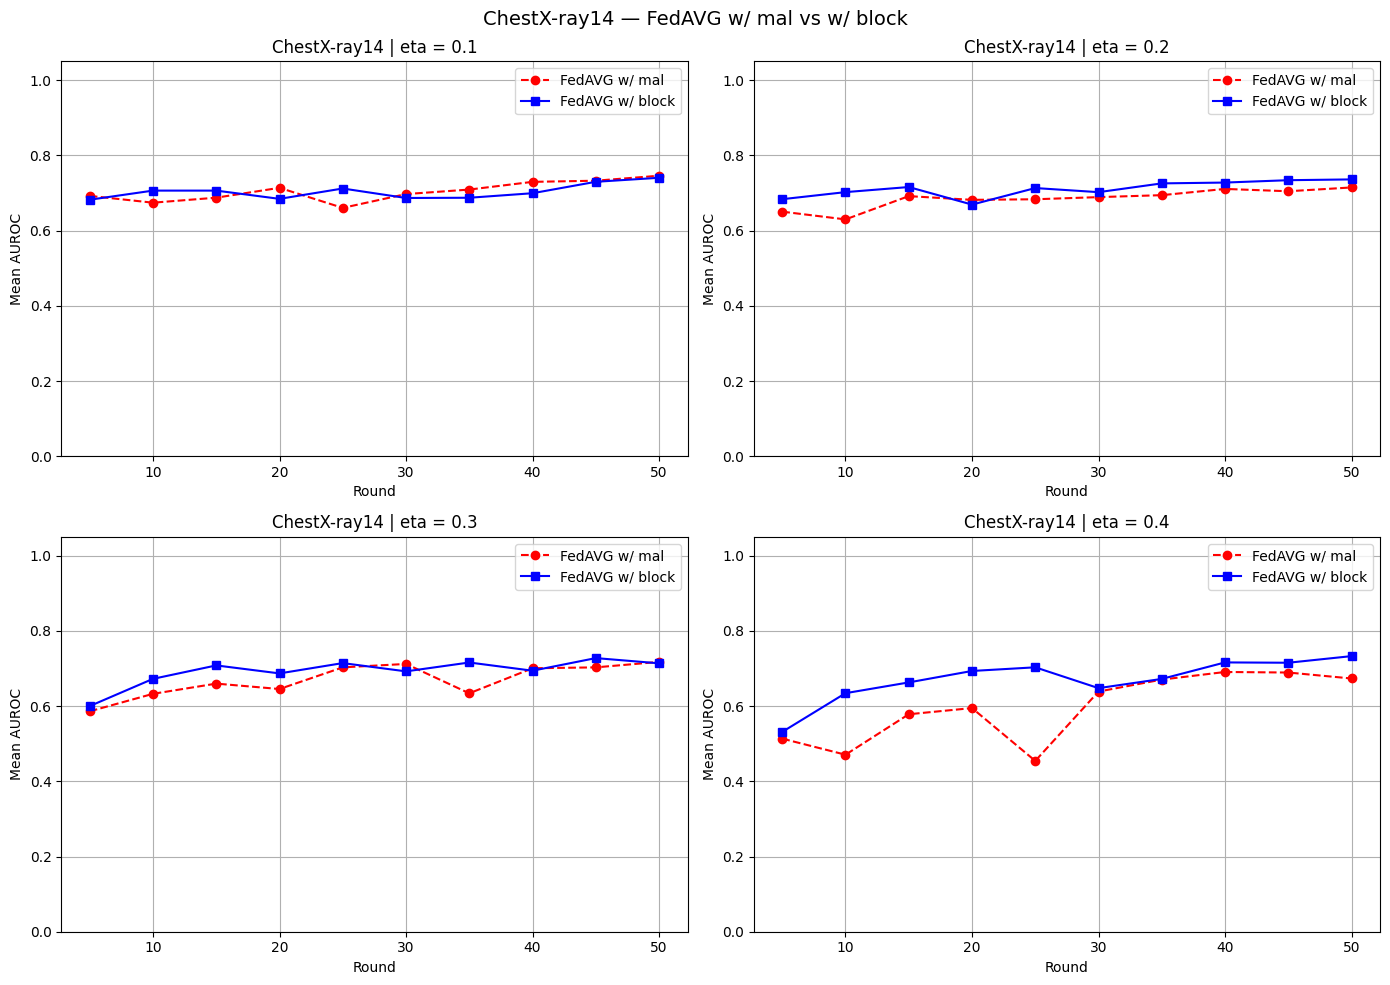

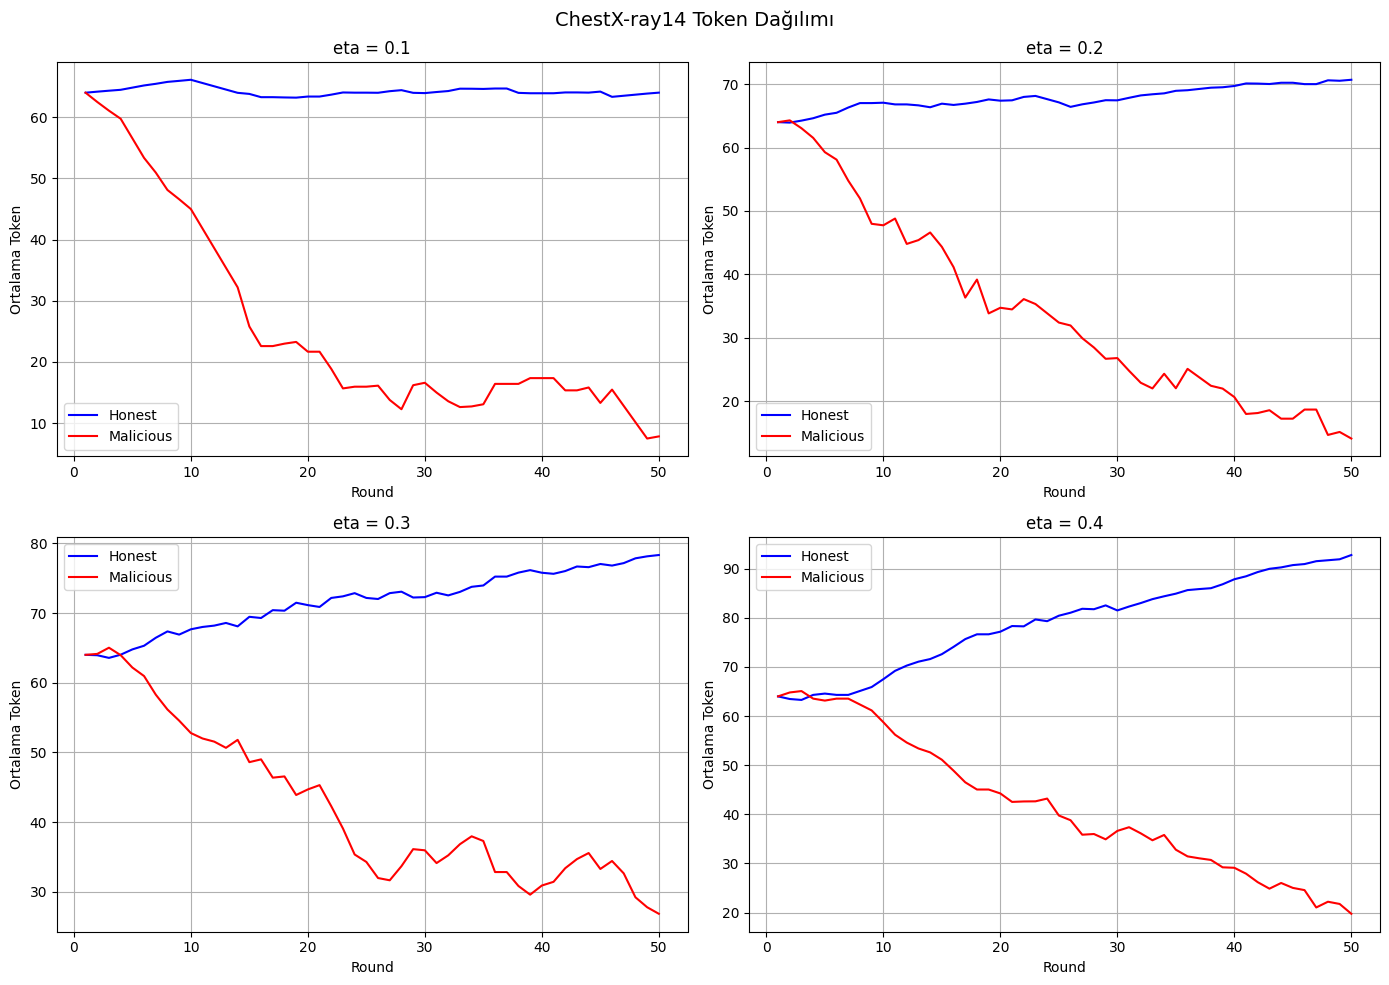


--- ChestX-ray14 Özet Tablosu ---
eta    w/ mal       w/ block
------------------------------
0.1    0.7360       0.7231
0.2    0.7100       0.7325
0.3    0.7070       0.7118
0.4    0.6844       0.7214


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, eta in enumerate(eta_values):
    ax = axes[i]
    rounds = range(5, NUM_ROUNDS+1, 5)
    ax.plot(rounds, results_cxr[eta],
            marker='o', label='FedAVG w/ mal', color='red', linestyle='--')
    bc_auroc = blockchain_results_cxr[eta]['aurocs']
    ax.plot(range(5, len(bc_auroc)*5+1, 5), bc_auroc,
            marker='s', label='FedAVG w/ block', color='blue')
    ax.set_title(f'ChestX-ray14 | eta = {eta}')
    ax.set_xlabel('Round')
    ax.set_ylabel('Mean AUROC')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0, 1.05)

plt.suptitle('ChestX-ray14 — FedAVG w/ mal vs w/ block', fontsize=14)
plt.tight_layout()
plt.savefig('cxr_comparison.png', dpi=150)
plt.show()

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
axes2 = axes2.flatten()

for i, eta in enumerate(eta_values):
    ax = axes2[i]
    mal_t = blockchain_results_cxr[eta]['token_mal']
    hon_t = blockchain_results_cxr[eta]['token_hon']
    ax.plot(range(1, len(hon_t)+1), hon_t, color='blue', label='Honest')
    ax.plot(range(1, len(mal_t)+1), mal_t, color='red', label='Malicious')
    ax.set_title(f'eta = {eta}')
    ax.set_xlabel('Round')
    ax.set_ylabel('Ortalama Token')
    ax.legend()
    ax.grid(True)

plt.suptitle('ChestX-ray14 Token Dağılımı', fontsize=14)
plt.tight_layout()
plt.savefig('cxr_tokens.png', dpi=150)
plt.show()

print("\n--- ChestX-ray14 Özet Tablosu ---")
print(f"{'eta':<6} {'w/ mal':<12} {'w/ block'}")
print("-" * 30)
for eta in eta_values:
    mal = np.mean(results_cxr[eta][-3:]) if results_cxr[eta] else 0
    blk = np.mean(blockchain_results_cxr[eta]['aurocs'][-3:]) \
          if blockchain_results_cxr[eta]['aurocs'] else 0
    print(f"{eta:<6} {mal:<12.4f} {blk:.4f}")

In [ ]:
# ─── Adaptive Gamma: Novelty Katkısı ───────────────────────────────────────
BASE_GAMMA = 8
GAMMA_MIN  = 2
GAMMA_MAX  = 16
WINDOW     = 10   # Son kaç round'a bakılacak

def adaptive_gamma(recent_decisions, base=BASE_GAMMA,
                   g_min=GAMMA_MIN, g_max=GAMMA_MAX):
    """
    Son WINDOW round'daki karar geçmişine göre gamma'yı ayarla.
    recent_decisions: list of 1 (accept) / -1 (reject)
    """
    if len(recent_decisions) < 3:
        return float(base)
    window = recent_decisions[-WINDOW:]
    reject_rate = window.count(-1) / len(window)
    if reject_rate > 0.4:
        gamma = min(base * 1.5, g_max)   # Saldırı fazla → sert ceza
    elif reject_rate < 0.1:
        gamma = max(base * 0.5, g_min)   # Sistem stabil → hafif ceza
    else:
        gamma = float(base)
    return gamma

print('✅ adaptive_gamma fonksiyonu tanımlandı.')
print(f'   BASE={BASE_GAMMA}, MIN={GAMMA_MIN}, MAX={GAMMA_MAX}, WINDOW={WINDOW}')

✅ adaptive_gamma fonksiyonu tanımlandı.
   BASE=8, MIN=2, MAX=16, WINDOW=10


In [ ]:
# ─── Lending Club — FedAVG w/ Adaptive Gamma ───────────────────────────────
import pickle, gc

adaptive_results_lc = {}

for eta in eta_values:
    print(f'\n--- Adaptive Gamma FL (LC) | eta = {eta} ---')
    num_malicious = int(K * eta)
    malicious_clients = set(np.random.choice(range(K), num_malicious, replace=False))
    tokens         = initialize_tokens(K)
    active_clients = set(range(K))
    global_model   = MLP(input_dim=input_dim_lc).to(device)
    prev_val_scores = {}
    test_accuracies = []
    token_history_mal = []
    token_history_hon = []
    decision_history  = []     # ← adaptive gamma için karar geçmişi
    gamma_history     = []     # ← izleme amaçlı

    for round_idx in tqdm(range(NUM_ROUNDS)):
        active_list = list(active_clients)
        if len(active_list) < 3:
            print(f'Yeterli istemci kalmadı, round {round_idx} durdu.')
            break

        # ── Adaptive gamma hesapla ──────────────────────────────────────────
        current_gamma = adaptive_gamma(decision_history)
        gamma_history.append(current_gamma)

        num_proposers = max(int(PROPOSER_FRAC * len(active_list)), 1)
        proposer_ids  = list(np.random.choice(active_list, num_proposers, replace=False))
        voter_ids     = [i for i in active_list if i not in proposer_ids]

        local_weights = []
        for idx in proposer_ids:
            w, _ = local_update(global_model, train_dataset_lc,
                                user_groups_lc[idx],
                                malicious=(idx in malicious_clients))
            local_weights.append(w)

        candidate_model = MLP(input_dim=input_dim_lc).to(device)
        candidate_model.load_state_dict(average_weights(local_weights))

        voter_scores = {}
        for idx in voter_ids:
            score = local_validation_score(candidate_model, train_dataset_lc,
                                           user_groups_lc[idx])
            voter_scores[idx] = 1.0 - score if idx in malicious_clients else score

        decision, votes = majority_vote(voter_scores, prev_val_scores)
        decision_history.append(decision)  # ← geçmişe ekle

        if decision == 1:
            global_model.load_state_dict(candidate_model.state_dict())
            for idx, score in voter_scores.items():
                prev_val_scores[idx] = score

        del candidate_model
        torch.cuda.empty_cache()

        # ── Reward/slash — adaptive gamma kullan ───────────────────────────
        tokens, removed_p, _ = reward_slash_proposers(
            tokens, proposer_ids, decision, gamma_p=current_gamma)
        tokens, removed_v    = reward_slash_voters(
            tokens, votes, decision, gamma_v=current_gamma)
        active_clients -= (removed_p | removed_v)

        mal_tokens = [tokens[i] for i in active_clients if i in malicious_clients]
        hon_tokens = [tokens[i] for i in active_clients if i not in malicious_clients]
        token_history_mal.append(np.mean(mal_tokens) if mal_tokens else 0)
        token_history_hon.append(np.mean(hon_tokens) if hon_tokens else 0)

        if (round_idx + 1) % 10 == 0:
            acc = test_model(global_model, test_dataset_lc)
            test_accuracies.append(acc)
            mal_rem = len([i for i in active_clients if i in malicious_clients])
            print(f'Round {round_idx+1} | Acc: {acc:.4f} | '
                  f'γ={current_gamma:.1f} | Aktif: {len(active_clients)} | Mal: {mal_rem}')

    adaptive_results_lc[eta] = {
        'accuracies':  test_accuracies,
        'token_mal':   token_history_mal,
        'token_hon':   token_history_hon,
        'gamma_history': gamma_history
    }
    with open('adaptive_results_lc_backup.pkl', 'wb') as f:
        pickle.dump(adaptive_results_lc, f)
    print(f'💾 adaptive_results_lc kaydedildi (eta={eta} tamamlandı)')

    del global_model
    torch.cuda.empty_cache()
    gc.collect()

print('\n✅ Lending Club Adaptive Gamma simülasyonu tamamlandı.')


--- Adaptive Gamma FL (LC) | eta = 0.1 ---


 20%|██        | 10/50 [00:03<00:14,  2.72it/s]

Round 10 | Acc: 0.9810 | γ=4.0 | Aktif: 50 | Mal: 5


 40%|████      | 20/50 [00:06<00:10,  2.86it/s]

Round 20 | Acc: 0.9924 | γ=4.0 | Aktif: 50 | Mal: 5


...

Round 30 | Acc: 0.9932 | γ=4.0 | Aktif: 30 | Mal: 0


 80%|████████  | 40/50 [00:09<00:02,  4.69it/s]

Round 40 | Acc: 0.9934 | γ=4.0 | Aktif: 30 | Mal: 0


100%|██████████| 50/50 [00:11<00:00,  4.54it/s]

Round 50 | Acc: 0.9942 | γ=4.0 | Aktif: 30 | Mal: 0
💾 adaptive_results_lc kaydedildi (eta=0.4 tamamlandı)

✅ Lending Club Adaptive Gamma simülasyonu tamamlandı.


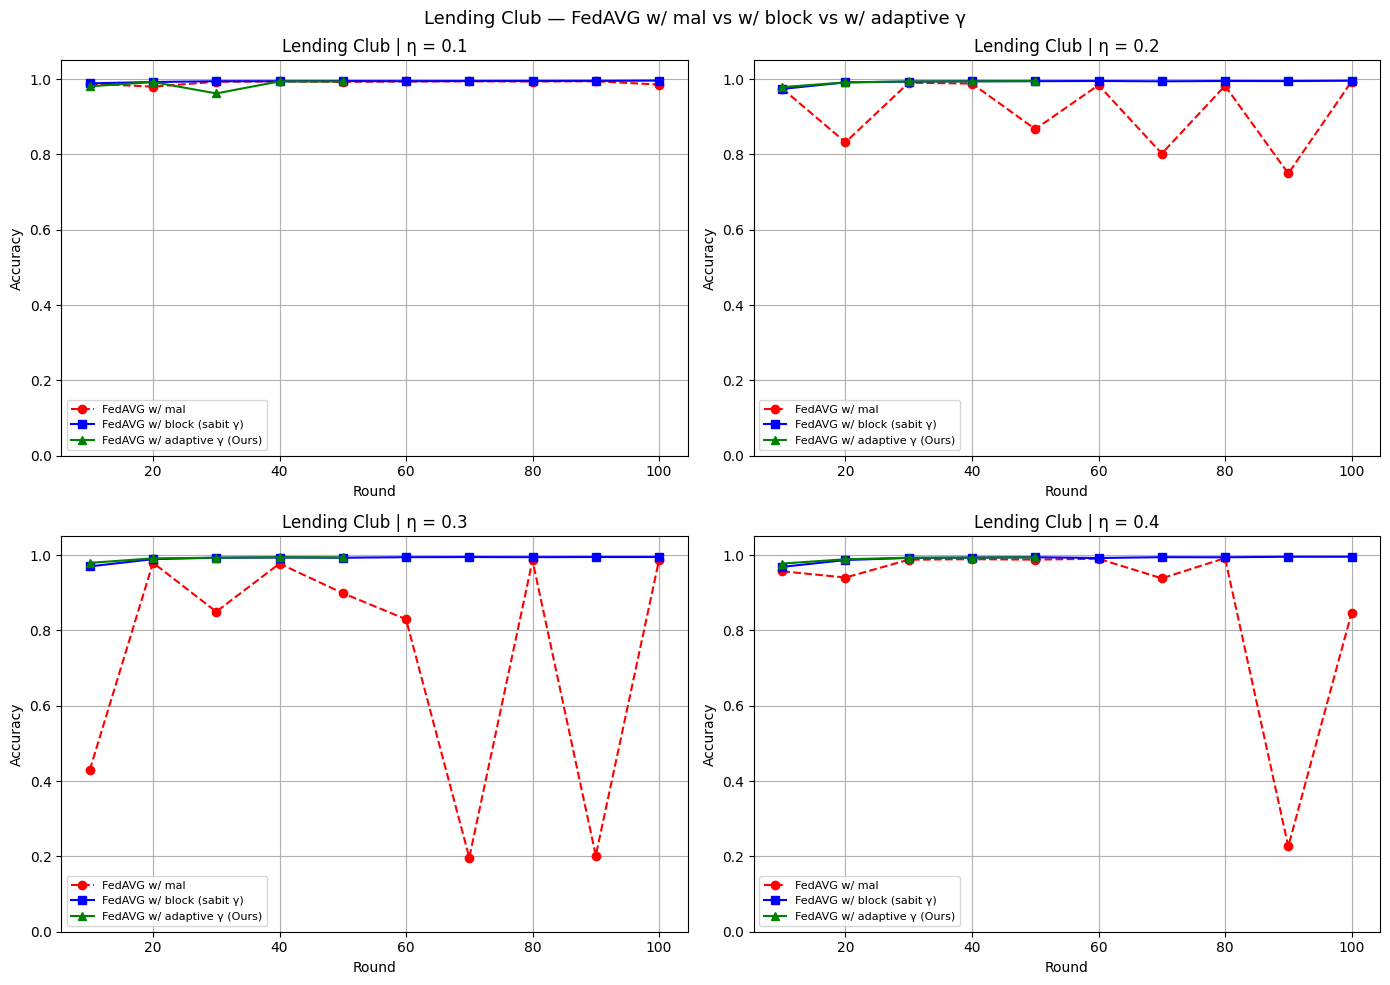

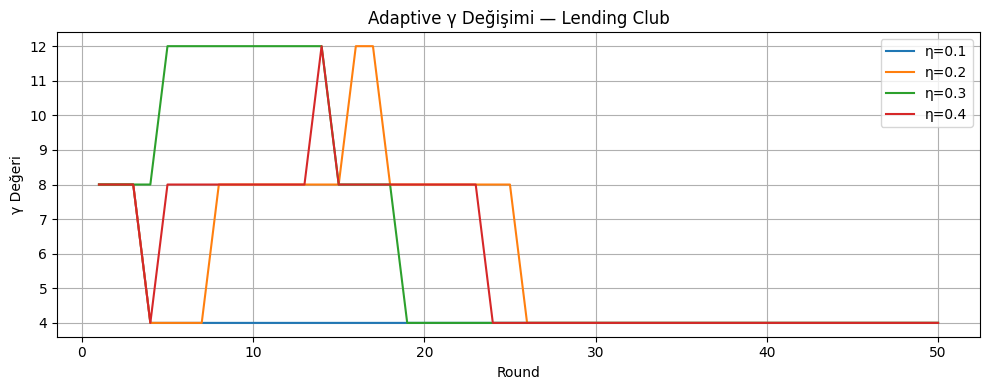


─── Lending Club Karşılaştırma Tablosu ───
eta    w/ mal       w/ block (γ=8)       w/ adaptive γ
----------------------------------------------------
0.1    0.9924       0.9953               0.9847
0.2    0.9025       0.9951               0.9907
0.3    0.6404       0.9949               0.9905
0.4    0.7988       0.9946               0.9895


In [ ]:
# ─── Lending Club: 3'lü karşılaştırma (w/mal, w/block, adaptive) ───────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, eta in enumerate(eta_values):
    ax = axes[i]
    # Kırmızı: saldırı altında vanilla FedAVG
    base_acc = results_lc[eta]
    ax.plot(range(10, len(base_acc)*10+1, 10), base_acc,
            marker='o', label='FedAVG w/ mal', color='red', linestyle='--')
    # Mavi: orijinal blockchain (sabit γ)
    bc_acc = blockchain_results_lc[eta]['accuracies']
    ax.plot(range(10, len(bc_acc)*10+1, 10), bc_acc,
            marker='s', label='FedAVG w/ block (sabit γ)', color='blue')
    # Yeşil: adaptive gamma (bizim novelty)
    ad_acc = adaptive_results_lc[eta]['accuracies']
    ax.plot(range(10, len(ad_acc)*10+1, 10), ad_acc,
            marker='^', label='FedAVG w/ adaptive γ (Ours)', color='green')
    ax.set_title(f'Lending Club | η = {eta}')
    ax.set_xlabel('Round')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_ylim(0, 1.05)

plt.suptitle('Lending Club — FedAVG w/ mal vs w/ block vs w/ adaptive γ', fontsize=13)
plt.tight_layout()
plt.savefig('lc_adaptive_comparison.png', dpi=150)
plt.show()

# ── Gamma geçmişi (eta=0.4 için örnek) ──────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4))
for eta in eta_values:
    gh = adaptive_results_lc[eta]['gamma_history']
    ax2.plot(range(1, len(gh)+1), gh, label=f'η={eta}')
ax2.set_title('Adaptive γ Değişimi — Lending Club')
ax2.set_xlabel('Round')
ax2.set_ylabel('γ Değeri')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig('lc_gamma_history.png', dpi=150)
plt.show()

# ── Özet tablo ───────────────────────────────────────────────────────────────
print('\n─── Lending Club Karşılaştırma Tablosu ───')
print(f'{"eta":<6} {"w/ mal":<12} {"w/ block (γ=8)":<20} {"w/ adaptive γ"}')
print('-' * 52)
for eta in eta_values:
    mal  = np.mean(results_lc[eta][-5:])
    blk  = np.mean(blockchain_results_lc[eta]['accuracies'][-5:]) \
           if blockchain_results_lc[eta]['accuracies'] else 0
    adp  = np.mean(adaptive_results_lc[eta]['accuracies'][-5:]) \
           if adaptive_results_lc[eta]['accuracies'] else 0
    print(f'{eta:<6} {mal:<12.4f} {blk:<20.4f} {adp:.4f}')

In [ ]:
# ─── ChestX-ray14 — FedAVG w/ Adaptive Gamma ───────────────────────────────
import pickle, gc

adaptive_results_cxr = {}

for eta in eta_values:
    print(f'\n--- Adaptive Gamma FL (CXR) | eta = {eta} ---')
    num_malicious = int(K * eta)
    malicious_clients = set(np.random.choice(range(K), num_malicious, replace=False))
    tokens         = initialize_tokens(K)
    active_clients = set(range(K))
    global_model   = DenseNet121().to(device)
    prev_val_scores = {}
    test_aurocs     = []
    token_history_mal = []
    token_history_hon = []
    decision_history  = []
    gamma_history     = []

    for round_idx in tqdm(range(NUM_ROUNDS)):
        active_list = list(active_clients)
        if len(active_list) < 3:
            print('⚠️ Yeterli istemci kalmadı.')
            break

        current_gamma = adaptive_gamma(decision_history)
        gamma_history.append(current_gamma)

        num_proposers = max(int(PROPOSER_FRAC * len(active_list)), 1)
        proposer_ids  = list(np.random.choice(active_list, num_proposers, replace=False))
        remaining     = [i for i in active_list if i not in proposer_ids]
        voter_ids     = list(np.random.choice(
            remaining, min(MAX_VOTERS, len(remaining)), replace=False))

        local_weights = []
        for idx in proposer_ids:
            w, _ = local_update_cxr(
                global_model, train_dataset_cxr,
                user_groups_cxr[idx],
                malicious=(idx in malicious_clients))
            local_weights.append(w)

        candidate_model = DenseNet121().to(device)
        avg_w = average_weights(local_weights)
        candidate_model.load_state_dict(
            {k: v.to(device, non_blocking=True) for k, v in avg_w.items()})

        voter_scores = {}
        for idx in voter_ids:
            score = local_validation_score_cxr(
                candidate_model, train_dataset_cxr, user_groups_cxr[idx])
            voter_scores[idx] = (1.0 - score) if idx in malicious_clients else score

        decision, votes = majority_vote(voter_scores, prev_val_scores)
        decision_history.append(decision)

        if decision == 1:
            global_model.load_state_dict(candidate_model.state_dict())
            for idx, score in voter_scores.items():
                prev_val_scores[idx] = score

        del candidate_model
        torch.cuda.empty_cache()
        gc.collect()

        tokens, removed_p, _ = reward_slash_proposers(
            tokens, proposer_ids, decision, gamma_p=current_gamma)
        tokens, removed_v    = reward_slash_voters(
            tokens, votes, decision, gamma_v=current_gamma)
        active_clients -= (removed_p | removed_v)

        mal_tokens = [tokens[i] for i in active_clients if i in malicious_clients]
        hon_tokens = [tokens[i] for i in active_clients if i not in malicious_clients]
        token_history_mal.append(np.mean(mal_tokens) if mal_tokens else 0)
        token_history_hon.append(np.mean(hon_tokens) if hon_tokens else 0)

        if (round_idx + 1) % 5 == 0:
            auroc = test_model_cxr(global_model, test_dataset_cxr)
            test_aurocs.append(auroc)
            mal_rem = len([i for i in active_clients if i in malicious_clients])
            print(f'Round {round_idx+1} | AUROC: {auroc:.4f} | '
                  f'γ={current_gamma:.1f} | Aktif: {len(active_clients)} | Mal: {mal_rem}')

    adaptive_results_cxr[eta] = {
        'aurocs':       test_aurocs,
        'token_mal':    token_history_mal,
        'token_hon':    token_history_hon,
        'gamma_history': gamma_history
    }
    with open('adaptive_results_cxr_backup.pkl', 'wb') as f:
        pickle.dump(adaptive_results_cxr, f)
    print(f'💾 adaptive_results_cxr kaydedildi (eta={eta} tamamlandı)')

    del global_model
    torch.cuda.empty_cache()
    gc.collect()

print('\n✅ CXR Adaptive Gamma simülasyonu tamamlandı.')


--- Adaptive Gamma FL (CXR) | eta = 0.1 ---


 10%|█         | 5/50 [00:25<04:08,  5.52s/it]

Round 5 | AUROC: 0.6110 | γ=4.0 | Aktif: 50 | Mal: 5


 20%|██        | 10/50 [00:51<03:44,  5.62s/it]

Round 10 | AUROC: 0.6789 | γ=4.0 | Aktif: 50 | Mal: 5


...

Round 40 | AUROC: 0.7207 | γ=4.0 | Aktif: 50 | Mal: 20


 90%|█████████ | 45/50 [03:51<00:24,  4.89s/it]

Round 45 | AUROC: 0.7325 | γ=8.0 | Aktif: 46 | Mal: 16


100%|██████████| 50/50 [04:13<00:00,  5.08s/it]

Round 50 | AUROC: 0.7465 | γ=8.0 | Aktif: 43 | Mal: 13
💾 adaptive_results_cxr kaydedildi (eta=0.4 tamamlandı)

✅ CXR Adaptive Gamma simülasyonu tamamlandı.


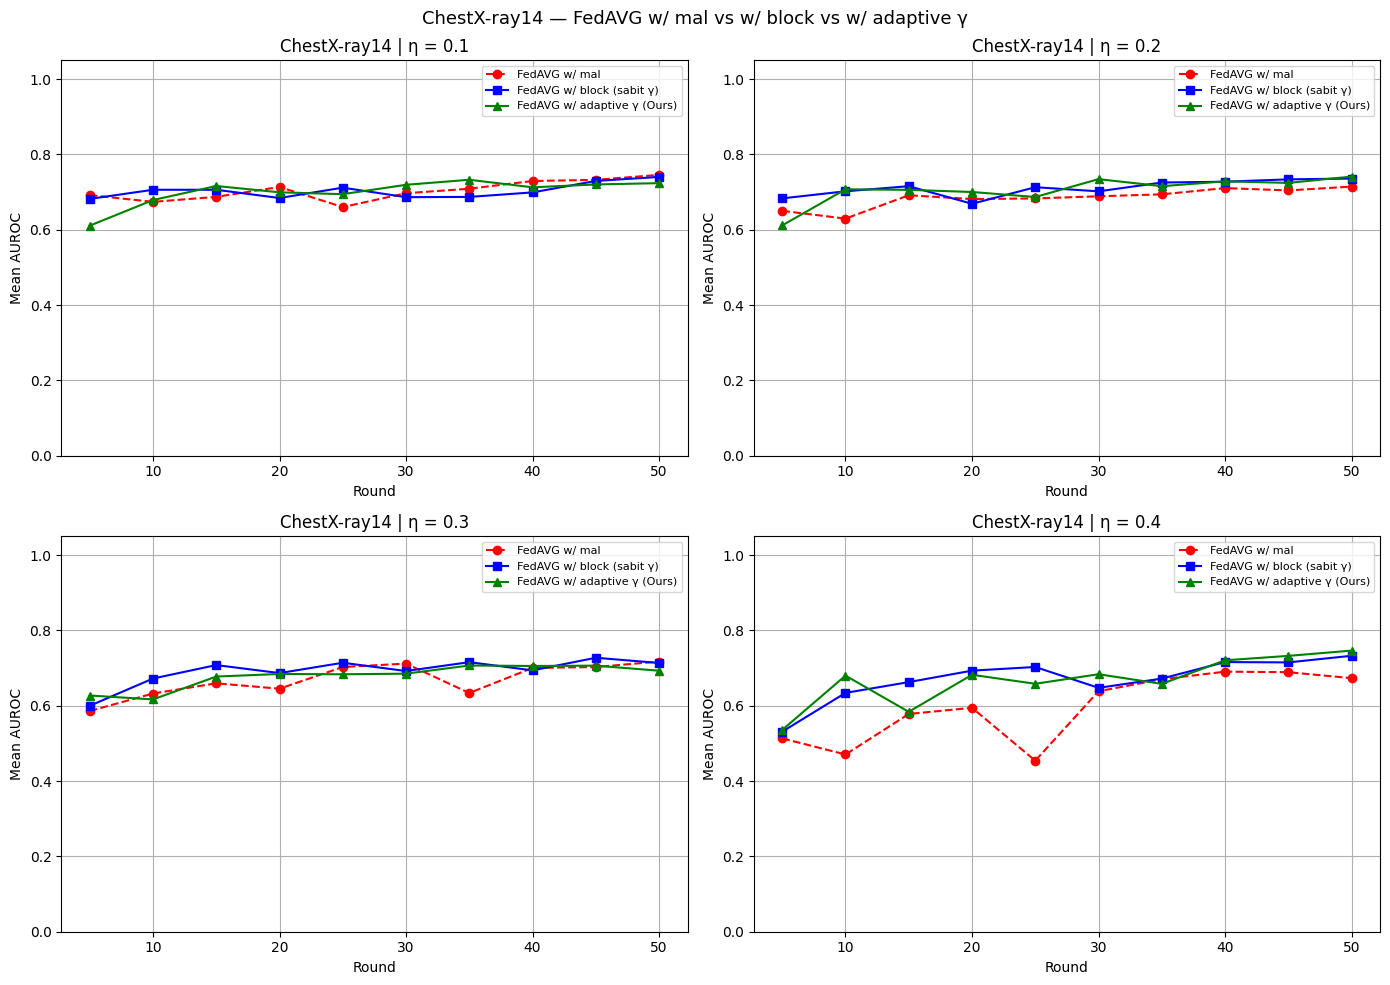


─── ChestX-ray14 Karşılaştırma Tablosu ───
eta    w/ mal       w/ block (γ=8)       w/ adaptive γ
----------------------------------------------------
0.1    0.7360       0.7231               0.7190
0.2    0.7100       0.7325               0.7314
0.3    0.7070       0.7118               0.7018
0.4    0.6844       0.7214               0.7333


In [ ]:
# ─── ChestX-ray14: 3'lü karşılaştırma ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, eta in enumerate(eta_values):
    ax = axes[i]
    rounds_mal = range(5, NUM_ROUNDS+1, 5)
    ax.plot(rounds_mal, results_cxr[eta],
            marker='o', label='FedAVG w/ mal', color='red', linestyle='--')
    bc_auroc = blockchain_results_cxr[eta]['aurocs']
    ax.plot(range(5, len(bc_auroc)*5+1, 5), bc_auroc,
            marker='s', label='FedAVG w/ block (sabit γ)', color='blue')
    ad_auroc = adaptive_results_cxr[eta]['aurocs']
    ax.plot(range(5, len(ad_auroc)*5+1, 5), ad_auroc,
            marker='^', label='FedAVG w/ adaptive γ (Ours)', color='green')
    ax.set_title(f'ChestX-ray14 | η = {eta}')
    ax.set_xlabel('Round')
    ax.set_ylabel('Mean AUROC')
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_ylim(0, 1.05)

plt.suptitle('ChestX-ray14 — FedAVG w/ mal vs w/ block vs w/ adaptive γ', fontsize=13)
plt.tight_layout()
plt.savefig('cxr_adaptive_comparison.png', dpi=150)
plt.show()

# ── Özet tablo ───────────────────────────────────────────────────────────────
print('\n─── ChestX-ray14 Karşılaştırma Tablosu ───')
print(f'{"eta":<6} {"w/ mal":<12} {"w/ block (γ=8)":<20} {"w/ adaptive γ"}')
print('-' * 52)
for eta in eta_values:
    mal  = np.mean(results_cxr[eta][-3:])  if results_cxr[eta]  else 0
    blk  = np.mean(blockchain_results_cxr[eta]['aurocs'][-3:]) \
           if blockchain_results_cxr[eta]['aurocs'] else 0
    adp  = np.mean(adaptive_results_cxr[eta]['aurocs'][-3:]) \
           if adaptive_results_cxr[eta]['aurocs'] else 0
    print(f'{eta:<6} {mal:<12.4f} {blk:<20.4f} {adp:.4f}')

In [ ]:
# ─── Reputation-Based Weighted Voting: Novelty 2 ───────────────────────────

REPUTATION_INIT  = 1.0   # başlangıç reputation
REPUTATION_MAX   = 5.0   # üst sınır (sonsuz büyümeyi engelle)
REPUTATION_MIN   = 0.1   # alt sınır (tamamen etkisiz olmasın)
REPUTATION_UP    = 0.1   # doğru oy → +0.1
REPUTATION_DOWN  = 0.2   # yanlış oy → -0.2

def initialize_reputations(num_clients):
    return {i: REPUTATION_INIT for i in range(num_clients)}

def weighted_majority_vote(voter_scores, prev_scores, reputations, epsilon=EPSILON):
    """
    Her voter'ın oyunu reputation ağırlığıyla çarparak karar verir.
    Dönüş: decision (1/-1), votes dict, weighted_sum (debug için)
    """
    votes = {}
    for voter_id, score in voter_scores.items():
        prev = prev_scores.get(voter_id, 0.0)
        if prev == 0.0:
            votes[voter_id] = 1
        elif score >= (1 - epsilon) * prev:
            votes[voter_id] = 1
        else:
            votes[voter_id] = -1

    # Reputation ağırlıklı toplam
    weighted_sum = sum(
        reputations.get(vid, REPUTATION_INIT) * v
        for vid, v in votes.items()
    )
    decision = 1 if weighted_sum > 0 else -1
    return decision, votes, weighted_sum

def update_reputations(reputations, votes, decision):
    """
    Round sonunda reputation güncelle:
    - Çoğunlukla aynı oy → +REPUTATION_UP
    - Azınlıkta kaldı    → -REPUTATION_DOWN
    Değerler [REPUTATION_MIN, REPUTATION_MAX] aralığında tutulur.
    """
    for vid, v in votes.items():
        if v == decision:
            reputations[vid] = min(reputations[vid] + REPUTATION_UP, REPUTATION_MAX)
        else:
            reputations[vid] = max(reputations[vid] - REPUTATION_DOWN, REPUTATION_MIN)
    return reputations

print('✅ Weighted voting fonksiyonları tanımlandı.')
print(f'   REPUTATION_INIT={REPUTATION_INIT}, UP={REPUTATION_UP}, DOWN={REPUTATION_DOWN}')
print(f'   Sınırlar: [{REPUTATION_MIN}, {REPUTATION_MAX}]')

✅ Weighted voting fonksiyonları tanımlandı.
   REPUTATION_INIT=1.0, UP=0.1, DOWN=0.2
   Sınırlar: [0.1, 5.0]


In [ ]:
# ─── Lending Club — FedAVG w/ Weighted Voting ──────────────────────────────
import pickle, gc

weighted_results_lc = {}

for eta in eta_values:
    print(f'\n--- Weighted Voting FL (LC) | eta = {eta} ---')
    num_malicious = int(K * eta)
    malicious_clients = set(np.random.choice(range(K), num_malicious, replace=False))
    tokens         = initialize_tokens(K)
    reputations    = initialize_reputations(K)   # ← yeni
    active_clients = set(range(K))
    global_model   = MLP(input_dim=input_dim_lc).to(device)
    prev_val_scores = {}
    test_accuracies = []
    token_history_mal = []
    token_history_hon = []
    rep_history_mal   = []   # malicious reputation takibi
    rep_history_hon   = []   # honest reputation takibi

    for round_idx in tqdm(range(NUM_ROUNDS)):
        active_list = list(active_clients)
        if len(active_list) < 3:
            print(f'Yeterli istemci kalmadı, round {round_idx} durdu.')
            break

        num_proposers = max(int(PROPOSER_FRAC * len(active_list)), 1)
        proposer_ids  = list(np.random.choice(active_list, num_proposers, replace=False))
        voter_ids     = [i for i in active_list if i not in proposer_ids]

        local_weights = []
        for idx in proposer_ids:
            w, _ = local_update(global_model, train_dataset_lc,
                                user_groups_lc[idx],
                                malicious=(idx in malicious_clients))
            local_weights.append(w)

        candidate_model = MLP(input_dim=input_dim_lc).to(device)
        candidate_model.load_state_dict(average_weights(local_weights))

        voter_scores = {}
        for idx in voter_ids:
            score = local_validation_score(candidate_model, train_dataset_lc,
                                           user_groups_lc[idx])
            voter_scores[idx] = 1.0 - score if idx in malicious_clients else score

        # ── Weighted vote ───────────────────────────────────────────────────
        decision, votes, _ = weighted_majority_vote(
            voter_scores, prev_val_scores, reputations)
        reputations = update_reputations(reputations, votes, decision)

        if decision == 1:
            global_model.load_state_dict(candidate_model.state_dict())
            for idx, score in voter_scores.items():
                prev_val_scores[idx] = score

        del candidate_model
        torch.cuda.empty_cache()

        tokens, removed_p, _ = reward_slash_proposers(tokens, proposer_ids, decision)
        tokens, removed_v    = reward_slash_voters(tokens, votes, decision)
        active_clients -= (removed_p | removed_v)
        # Çıkarılan client'ların reputasyonunu da sil
        for rid in (removed_p | removed_v):
            reputations.pop(rid, None)

        mal_tokens = [tokens[i] for i in active_clients if i in malicious_clients]
        hon_tokens = [tokens[i] for i in active_clients if i not in malicious_clients]
        token_history_mal.append(np.mean(mal_tokens) if mal_tokens else 0)
        token_history_hon.append(np.mean(hon_tokens) if hon_tokens else 0)

        mal_reps = [reputations[i] for i in active_clients
                    if i in malicious_clients and i in reputations]
        hon_reps = [reputations[i] for i in active_clients
                    if i not in malicious_clients and i in reputations]
        rep_history_mal.append(np.mean(mal_reps) if mal_reps else 0)
        rep_history_hon.append(np.mean(hon_reps) if hon_reps else 0)

        if (round_idx + 1) % 10 == 0:
            acc = test_model(global_model, test_dataset_lc)
            test_accuracies.append(acc)
            mal_rem = len([i for i in active_clients if i in malicious_clients])
            avg_mal_rep = np.mean(mal_reps) if mal_reps else 0
            avg_hon_rep = np.mean(hon_reps) if hon_reps else 0
            print(f'Round {round_idx+1} | Acc: {acc:.4f} | '
                  f'Aktif: {len(active_clients)} | Mal: {mal_rem} | '
                  f'Rep(mal)={avg_mal_rep:.2f} Rep(hon)={avg_hon_rep:.2f}')

    weighted_results_lc[eta] = {
        'accuracies':   test_accuracies,
        'token_mal':    token_history_mal,
        'token_hon':    token_history_hon,
        'rep_mal':      rep_history_mal,
        'rep_hon':      rep_history_hon
    }
    with open('weighted_results_lc_backup.pkl', 'wb') as f:
        pickle.dump(weighted_results_lc, f)
    print(f'💾 weighted_results_lc kaydedildi (eta={eta} tamamlandı)')

    del global_model
    torch.cuda.empty_cache()
    gc.collect()

print('\n✅ Lending Club Weighted Voting simülasyonu tamamlandı.')


--- Weighted Voting FL (LC) | eta = 0.1 ---


 20%|██        | 10/50 [00:03<00:13,  2.99it/s]

Round 10 | Acc: 0.9889 | Aktif: 50 | Mal: 5 | Rep(mal)=0.26 Rep(hon)=1.85


 40%|████      | 20/50 [00:05<00:08,  3.40it/s]

Round 20 | Acc: 0.9927 | Aktif: 45 | Mal: 0 | Rep(mal)=0.00 Rep(hon)=2.76


...

Round 30 | Acc: 0.9941 | Aktif: 30 | Mal: 0 | Rep(mal)=0.00 Rep(hon)=3.52


 82%|████████▏ | 41/50 [00:08<00:01,  5.10it/s]

Round 40 | Acc: 0.9938 | Aktif: 30 | Mal: 0 | Rep(mal)=0.00 Rep(hon)=4.42


100%|██████████| 50/50 [00:10<00:00,  4.83it/s]

Round 50 | Acc: 0.9948 | Aktif: 30 | Mal: 0 | Rep(mal)=0.00 Rep(hon)=4.94
💾 weighted_results_lc kaydedildi (eta=0.4 tamamlandı)

✅ Lending Club Weighted Voting simülasyonu tamamlandı.


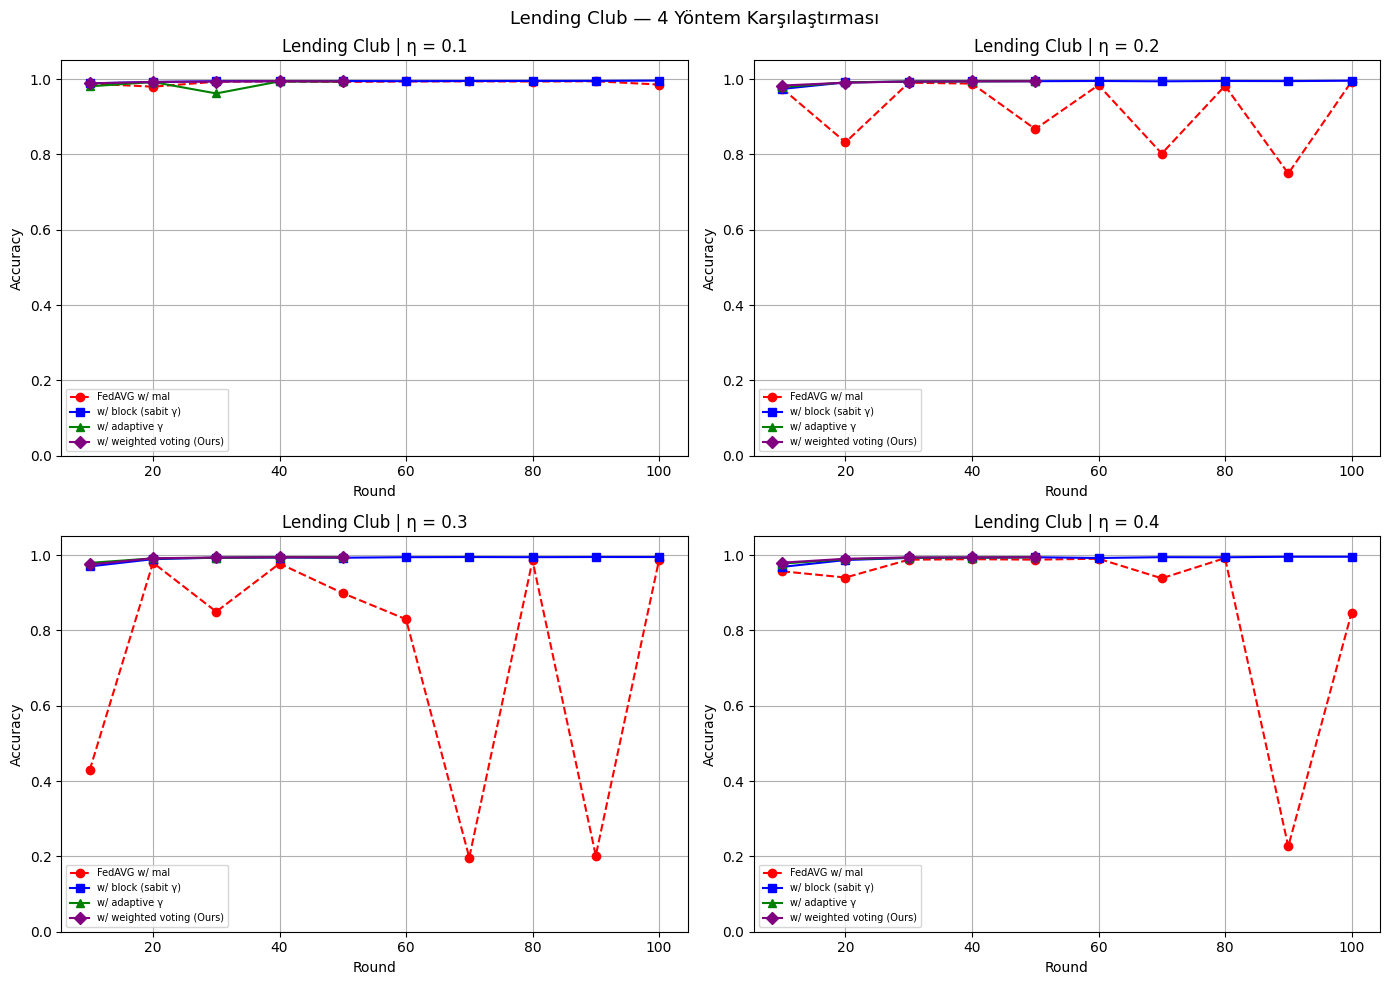

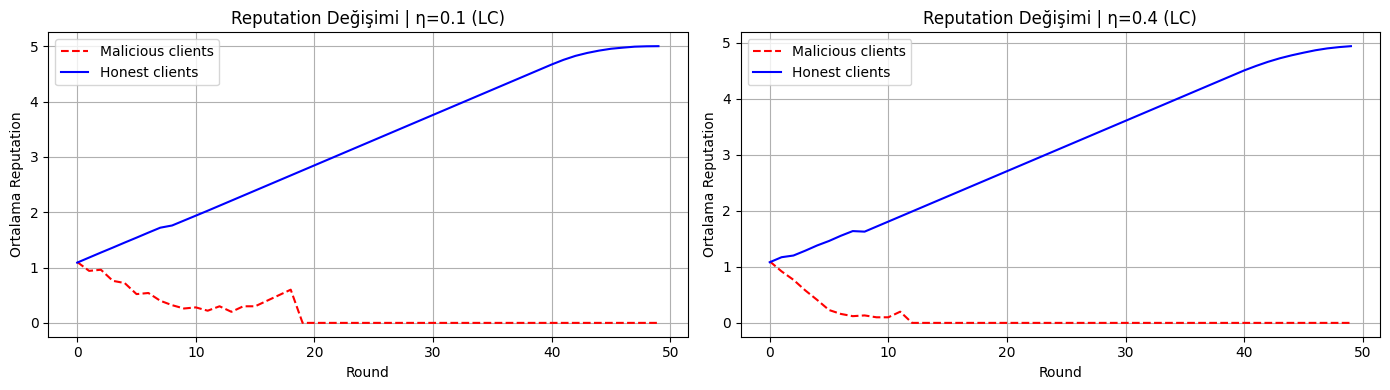


─── Lending Club Tam Karşılaştırma Tablosu ───
eta    w/ mal       w/ block     adaptive γ     weighted voting
------------------------------------------------------------
0.1    0.9924       0.9953       0.9847         0.9928
0.2    0.9025       0.9951       0.9907         0.9912
0.3    0.6404       0.9949       0.9905         0.9899
0.4    0.7988       0.9946       0.9895         0.9907


In [ ]:
# ─── Lending Club: 4'lü karşılaştırma (mal, block, adaptive, weighted) ─────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, eta in enumerate(eta_values):
    ax = axes[i]
    # Kırmızı: saldırı altında vanilla FedAVG
    base_acc = results_lc[eta]
    ax.plot(range(10, len(base_acc)*10+1, 10), base_acc,
            marker='o', label='FedAVG w/ mal', color='red', linestyle='--')
    bc_acc = blockchain_results_lc[eta]['accuracies']
    ax.plot(range(10, len(bc_acc)*10+1, 10), bc_acc,
            marker='s', label='w/ block (sabit γ)', color='blue')
    ad_acc = adaptive_results_lc[eta]['accuracies']
    ax.plot(range(10, len(ad_acc)*10+1, 10), ad_acc,
            marker='^', label='w/ adaptive γ', color='green')
    wt_acc = weighted_results_lc[eta]['accuracies']
    ax.plot(range(10, len(wt_acc)*10+1, 10), wt_acc,
            marker='D', label='w/ weighted voting (Ours)', color='purple')
    ax.set_title(f'Lending Club | η = {eta}')
    ax.set_xlabel('Round')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.set_ylim(0, 1.05)

plt.suptitle('Lending Club — 4 Yöntem Karşılaştırması', fontsize=13)
plt.tight_layout()
plt.savefig('lc_weighted_comparison.png', dpi=150)
plt.show()

# ── Reputation grafiği (η=0.3 örneği) ────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
for j, eta in enumerate([0.1, 0.4]):
    ax = axes2[j]
    ax.plot(weighted_results_lc[eta]['rep_mal'],
            label='Malicious clients', color='red', linestyle='--')
    ax.plot(weighted_results_lc[eta]['rep_hon'],
            label='Honest clients', color='blue')
    ax.set_title(f'Reputation Değişimi | η={eta} (LC)')
    ax.set_xlabel('Round')
    ax.set_ylabel('Ortalama Reputation')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig('lc_reputation_history.png', dpi=150)
plt.show()

# ── Özet tablo ─────────────────────────────────────────────────────────────
print('\n─── Lending Club Tam Karşılaştırma Tablosu ───')
print(f'{"eta":<6} {"w/ mal":<12} {"w/ block":<12} {"adaptive γ":<14} {"weighted voting"}')
print('-' * 60)
for eta in eta_values:
    mal = np.mean(results_lc[eta][-5:])
    blk = np.mean(blockchain_results_lc[eta]['accuracies'][-5:]) \
          if blockchain_results_lc[eta]['accuracies'] else 0
    adp = np.mean(adaptive_results_lc[eta]['accuracies'][-5:]) \
          if adaptive_results_lc[eta]['accuracies'] else 0
    wt  = np.mean(weighted_results_lc[eta]['accuracies'][-5:]) \
          if weighted_results_lc[eta]['accuracies'] else 0
    print(f'{eta:<6} {mal:<12.4f} {blk:<12.4f} {adp:<14.4f} {wt:.4f}')

In [ ]:
# ─── ChestX-ray14 — FedAVG w/ Weighted Voting ──────────────────────────────
import pickle, gc

weighted_results_cxr = {}

for eta in eta_values:
    print(f'\n--- Weighted Voting FL (CXR) | eta = {eta} ---')
    num_malicious = int(K * eta)
    malicious_clients = set(np.random.choice(range(K), num_malicious, replace=False))
    tokens         = initialize_tokens(K)
    reputations    = initialize_reputations(K)
    active_clients = set(range(K))
    global_model   = DenseNet121().to(device)
    prev_val_scores = {}
    test_aurocs     = []
    token_history_mal = []
    token_history_hon = []
    rep_history_mal   = []
    rep_history_hon   = []

    for round_idx in tqdm(range(NUM_ROUNDS)):
        active_list = list(active_clients)
        if len(active_list) < 3:
            print('⚠️ Yeterli istemci kalmadı.')
            break

        num_proposers = max(int(PROPOSER_FRAC * len(active_list)), 1)
        proposer_ids  = list(np.random.choice(active_list, num_proposers, replace=False))
        remaining     = [i for i in active_list if i not in proposer_ids]
        voter_ids     = list(np.random.choice(
            remaining, min(MAX_VOTERS, len(remaining)), replace=False))

        local_weights = []
        for idx in proposer_ids:
            w, _ = local_update_cxr(
                global_model, train_dataset_cxr,
                user_groups_cxr[idx],
                malicious=(idx in malicious_clients))
            local_weights.append(w)

        candidate_model = DenseNet121().to(device)
        avg_w = average_weights(local_weights)
        candidate_model.load_state_dict(
            {k: v.to(device, non_blocking=True) for k, v in avg_w.items()})

        voter_scores = {}
        for idx in voter_ids:
            score = local_validation_score_cxr(
                candidate_model, train_dataset_cxr, user_groups_cxr[idx])
            voter_scores[idx] = (1.0 - score) if idx in malicious_clients else score

        decision, votes, _ = weighted_majority_vote(
            voter_scores, prev_val_scores, reputations)
        reputations = update_reputations(reputations, votes, decision)

        if decision == 1:
            global_model.load_state_dict(candidate_model.state_dict())
            for idx, score in voter_scores.items():
                prev_val_scores[idx] = score

        del candidate_model
        torch.cuda.empty_cache()
        gc.collect()

        tokens, removed_p, _ = reward_slash_proposers(tokens, proposer_ids, decision)
        tokens, removed_v    = reward_slash_voters(tokens, votes, decision)
        active_clients -= (removed_p | removed_v)
        for rid in (removed_p | removed_v):
            reputations.pop(rid, None)

        mal_tokens = [tokens[i] for i in active_clients if i in malicious_clients]
        hon_tokens = [tokens[i] for i in active_clients if i not in malicious_clients]
        token_history_mal.append(np.mean(mal_tokens) if mal_tokens else 0)
        token_history_hon.append(np.mean(hon_tokens) if hon_tokens else 0)

        mal_reps = [reputations[i] for i in active_clients
                    if i in malicious_clients and i in reputations]
        hon_reps = [reputations[i] for i in active_clients
                    if i not in malicious_clients and i in reputations]
        rep_history_mal.append(np.mean(mal_reps) if mal_reps else 0)
        rep_history_hon.append(np.mean(hon_reps) if hon_reps else 0)

        if (round_idx + 1) % 5 == 0:
            auroc = test_model_cxr(global_model, test_dataset_cxr)
            test_aurocs.append(auroc)
            mal_rem = len([i for i in active_clients if i in malicious_clients])
            avg_mal_rep = np.mean(mal_reps) if mal_reps else 0
            avg_hon_rep = np.mean(hon_reps) if hon_reps else 0
            print(f'Round {round_idx+1} | AUROC: {auroc:.4f} | '
                  f'Aktif: {len(active_clients)} | Mal: {mal_rem} | '
                  f'Rep(mal)={avg_mal_rep:.2f} Rep(hon)={avg_hon_rep:.2f}')

    weighted_results_cxr[eta] = {
        'aurocs':       test_aurocs,
        'token_mal':    token_history_mal,
        'token_hon':    token_history_hon,
        'rep_mal':      rep_history_mal,
        'rep_hon':      rep_history_hon
    }
    with open('weighted_results_cxr_backup.pkl', 'wb') as f:
        pickle.dump(weighted_results_cxr, f)
    print(f'💾 weighted_results_cxr kaydedildi (eta={eta} tamamlandı)')

    del global_model
    torch.cuda.empty_cache()
    gc.collect()

print('\n✅ CXR Weighted Voting simülasyonu tamamlandı.')


--- Weighted Voting FL (CXR) | eta = 0.1 ---


 10%|█         | 5/50 [00:26<04:14,  5.66s/it]

Round 5 | AUROC: 0.6558 | Aktif: 50 | Mal: 5 | Rep(mal)=0.86 Rep(hon)=1.14


 20%|██        | 10/50 [00:52<03:34,  5.35s/it]

Round 10 | AUROC: 0.6806 | Aktif: 50 | Mal: 5 | Rep(mal)=0.74 Rep(hon)=1.29


...

Round 40 | AUROC: 0.6801 | Aktif: 49 | Mal: 19 | Rep(mal)=0.56 Rep(hon)=1.68


 90%|█████████ | 45/50 [03:52<00:23,  4.65s/it]

Round 45 | AUROC: 0.6880 | Aktif: 46 | Mal: 16 | Rep(mal)=0.51 Rep(hon)=1.80


100%|██████████| 50/50 [04:16<00:00,  5.12s/it]

Round 50 | AUROC: 0.7456 | Aktif: 43 | Mal: 13 | Rep(mal)=0.48 Rep(hon)=1.96
💾 weighted_results_cxr kaydedildi (eta=0.4 tamamlandı)

✅ CXR Weighted Voting simülasyonu tamamlandı.


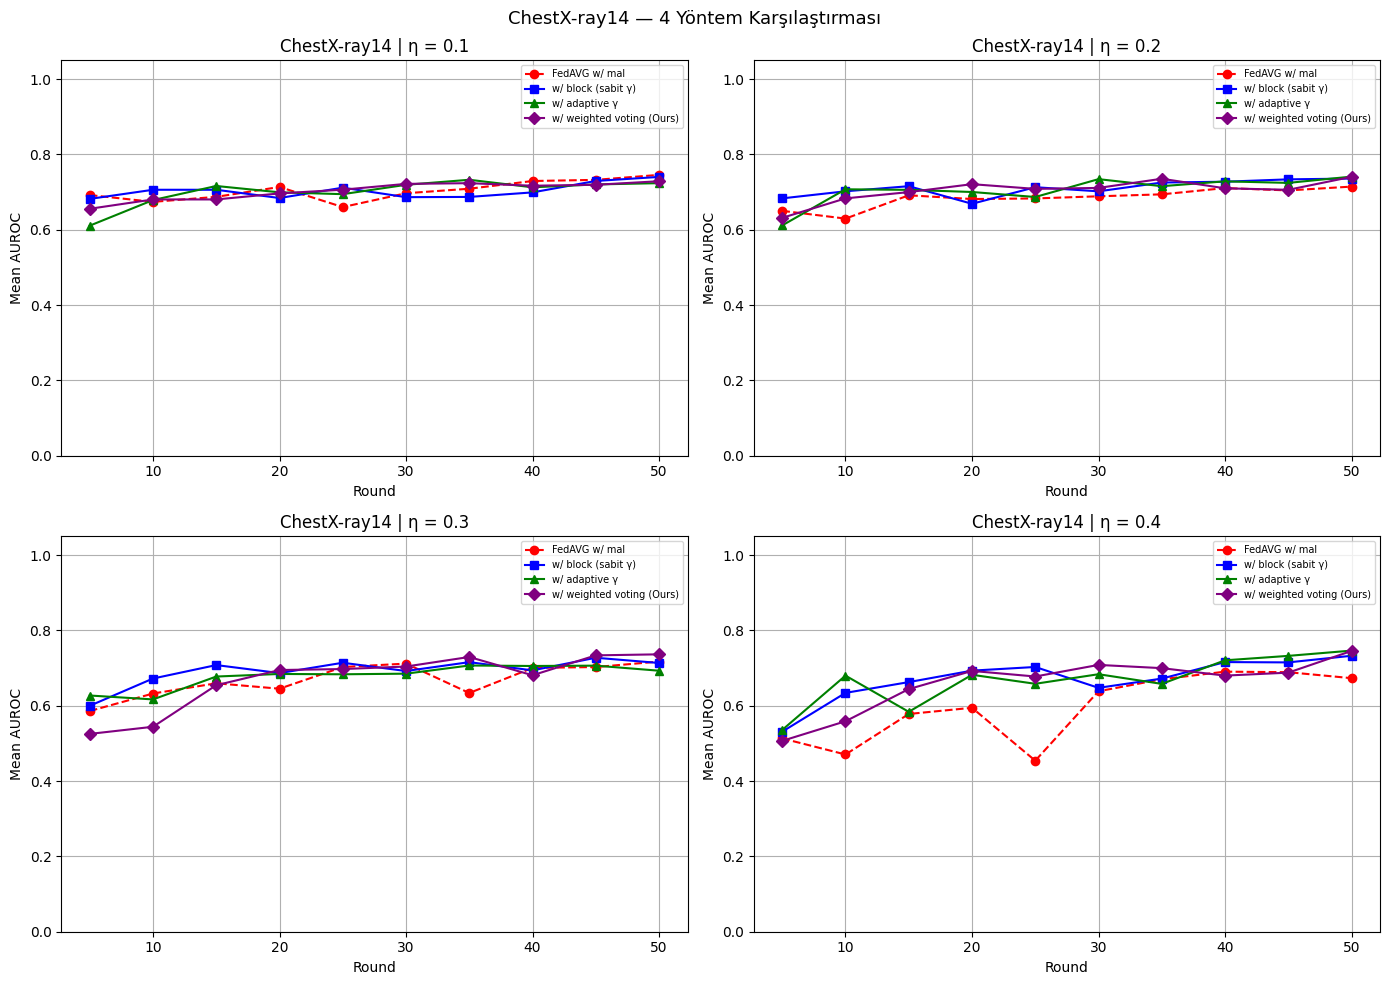

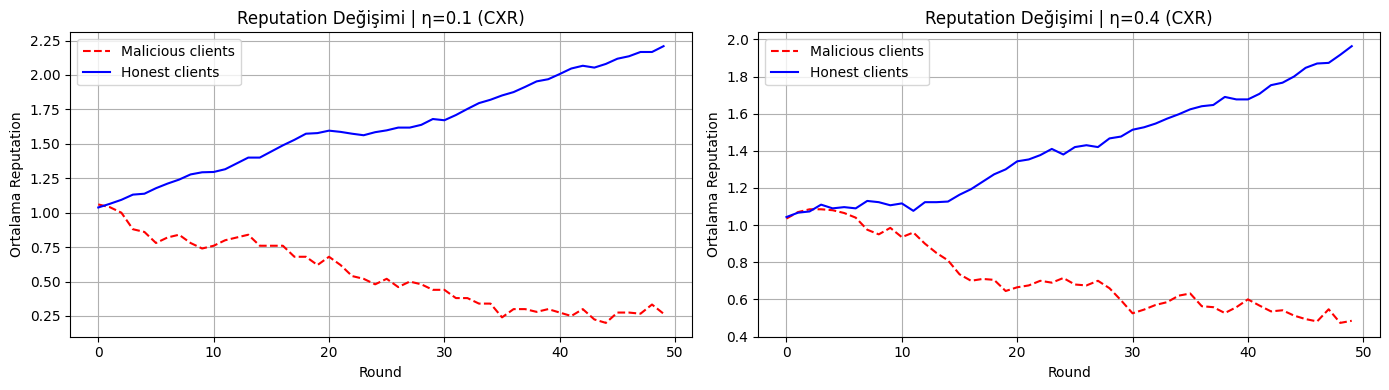


─── ChestX-ray14 Tam Karşılaştırma Tablosu ───
eta    w/ mal       w/ block     adaptive γ     weighted voting
------------------------------------------------------------
0.1    0.7360       0.7231       0.7190         0.7218
0.2    0.7100       0.7325       0.7314         0.7190
0.3    0.7070       0.7118       0.7018         0.7172
0.4    0.6844       0.7214       0.7333         0.7046


In [ ]:
# ─── ChestX-ray14: 4'lü karşılaştırma ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, eta in enumerate(eta_values):
    ax = axes[i]
    rounds_mal = list(range(5, NUM_ROUNDS+1, 5))
    ax.plot(rounds_mal, results_cxr[eta],
            marker='o', label='FedAVG w/ mal', color='red', linestyle='--')
    bc_auroc = blockchain_results_cxr[eta]['aurocs']
    ax.plot(range(5, len(bc_auroc)*5+1, 5), bc_auroc,
            marker='s', label='w/ block (sabit γ)', color='blue')
    ad_auroc = adaptive_results_cxr[eta]['aurocs']
    ax.plot(range(5, len(ad_auroc)*5+1, 5), ad_auroc,
            marker='^', label='w/ adaptive γ', color='green')
    wt_auroc = weighted_results_cxr[eta]['aurocs']
    ax.plot(range(5, len(wt_auroc)*5+1, 5), wt_auroc,
            marker='D', label='w/ weighted voting (Ours)', color='purple')
    ax.set_title(f'ChestX-ray14 | η = {eta}')
    ax.set_xlabel('Round')
    ax.set_ylabel('Mean AUROC')
    ax.legend(fontsize=7)
    ax.grid(True)
    ax.set_ylim(0, 1.05)

plt.suptitle('ChestX-ray14 — 4 Yöntem Karşılaştırması', fontsize=13)
plt.tight_layout()
plt.savefig('cxr_weighted_comparison.png', dpi=150)
plt.show()

# ── Reputation grafiği ────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
for j, eta in enumerate([0.1, 0.4]):
    ax = axes2[j]
    ax.plot(weighted_results_cxr[eta]['rep_mal'],
            label='Malicious clients', color='red', linestyle='--')
    ax.plot(weighted_results_cxr[eta]['rep_hon'],
            label='Honest clients', color='blue')
    ax.set_title(f'Reputation Değişimi | η={eta} (CXR)')
    ax.set_xlabel('Round')
    ax.set_ylabel('Ortalama Reputation')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig('cxr_reputation_history.png', dpi=150)
plt.show()

# ── Özet tablo ─────────────────────────────────────────────────────────────
print('\n─── ChestX-ray14 Tam Karşılaştırma Tablosu ───')
print(f'{"eta":<6} {"w/ mal":<12} {"w/ block":<12} {"adaptive γ":<14} {"weighted voting"}')
print('-' * 60)
for eta in eta_values:
    mal = np.mean(results_cxr[eta][-3:])  if results_cxr[eta]  else 0
    blk = np.mean(blockchain_results_cxr[eta]['aurocs'][-3:]) \
          if blockchain_results_cxr[eta]['aurocs'] else 0
    adp = np.mean(adaptive_results_cxr[eta]['aurocs'][-3:]) \
          if adaptive_results_cxr[eta]['aurocs'] else 0
    wt  = np.mean(weighted_results_cxr[eta]['aurocs'][-3:]) \
          if weighted_results_cxr[eta]['aurocs'] else 0
    print(f'{eta:<6} {mal:<12.4f} {blk:<12.4f} {adp:<14.4f} {wt:.4f}')